# Supervised vs Unsupervised Anomaly Detection

In [1]:
!pip install torch_geometric
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
import torch


from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import torch.optim as optim
import torch.nn as nn
import torch

from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from scipy.io.arff import loadarff
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans, DBSCAN
from sklearn.svm import OneClassSVM

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score, silhouette_samples, pairwise_distances_argmin_min
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.compose import ColumnTransformer


In [3]:
# Install gdown2
!pip install -q gdown

import gdown
import pandas as pd

# Google Drive file IDs
train_id = "1d7phRsswqxoGghddSjmEDpneHB-4LfeN"
test_id  = "1tjSKg_6_jLc2Iyc8CV9oR_i-k-4S--g2"

# Build direct download URLs
train_url = f"https://drive.google.com/uc?id={train_id}"
test_url  = f"https://drive.google.com/uc?id={test_id}"

# Download files
gdown.download(train_url, "train.csv", quiet=False)
gdown.download(test_url, "test.csv", quiet=False)

# Load into DataFrames
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Quick check
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Downloading...
From: https://drive.google.com/uc?id=1d7phRsswqxoGghddSjmEDpneHB-4LfeN
To: /content/train.csv
100%|██████████| 2.59M/2.59M [00:00<00:00, 65.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tjSKg_6_jLc2Iyc8CV9oR_i-k-4S--g2
To: /content/test.csv
100%|██████████| 802k/802k [00:00<00:00, 91.7MB/s]


Train shape: (18831, 43)
Test shape: (5826, 43)


# Dataset Characterization and Preprocessing

##  Explore the dataset

In [4]:
train_df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'binary_label'],
      dtype='object')

In [5]:
len(train_df.columns)

43

In [6]:
train_df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
0,0,udp,private,SF,28,0,0,3,0,0,...,0.36,0.65,0.36,0.00,0.09,0.0,0.56,0.0,dos,1
1,0,icmp,eco_i,SF,8,0,0,0,0,0,...,1.00,0.00,1.00,0.50,0.00,0.0,0.00,0.0,probe,1
2,0,tcp,daytime,S0,0,0,0,0,0,0,...,0.02,0.05,0.00,0.00,1.00,1.0,0.00,0.0,dos,1
3,0,tcp,http,SF,216,3396,0,0,0,0,...,1.00,0.00,0.14,0.02,0.00,0.0,0.00,0.0,normal,0
4,0,tcp,http,SF,348,277,0,0,0,0,...,1.00,0.00,0.01,0.07,0.00,0.0,0.00,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18826,0,tcp,http,SF,328,1231,0,0,0,0,...,1.00,0.00,0.02,0.02,0.00,0.0,0.00,0.0,normal,0
18827,0,tcp,http,SF,214,928,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,normal,0
18828,0,tcp,http,SF,253,11905,0,0,0,0,...,1.00,0.00,0.01,0.02,0.00,0.0,0.00,0.0,normal,0
18829,0,tcp,uucp_path,S0,0,0,0,0,0,0,...,0.05,0.07,0.00,0.00,1.00,1.0,0.00,0.0,dos,1


In [7]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,binary_label
count,18831.000000,1.883100e+04,1.883100e+04,18831.000000,18831.000000,18831.0,18831.000000,18831.000000,18831.000000,18831.000000,...,18831.000000,18831.000000,18831.000000,18831.000000,18831.000000,18831.000000,18831.000000,18831.000000,18831.000000,18831.000000
mean,407.959057,3.254533e+04,3.238093e+03,0.000053,0.029844,0.0,0.261324,0.001062,0.527269,0.301630,...,149.129149,0.672539,0.087955,0.194628,0.042004,0.104171,0.097172,0.101902,0.103238,0.285858
std,3100.606651,2.788382e+06,5.902675e+04,0.007287,0.297558,0.0,2.481723,0.047216,0.499269,12.044815,...,108.178912,0.416083,0.215677,0.341369,0.125548,0.293563,0.291542,0.278802,0.295504,0.451834
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,8.000000e+00,0.000000e+00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,21.000000,0.170000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,2.070000e+02,1.360000e+02,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,...,188.000000,1.000000,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,3.140000e+02,1.307500e+03,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.060000,0.180000,0.020000,0.000000,0.000000,0.000000,0.000000,1.000000
max,42862.000000,3.817091e+08,5.131424e+06,1.000000,3.000000,0.0,77.000000,4.000000,1.000000,884.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
test_df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
0,0,udp,private,SF,1,0,0,0,0,0,...,0.03,0.85,1.00,0.0,0.0,0.0,0.0,0.0,normal,0
1,0,udp,private,SF,55,51,0,0,0,0,...,1.00,0.00,0.99,0.0,0.0,0.0,0.0,0.0,normal,0
2,0,tcp,login,RSTO,0,0,0,0,0,0,...,0.07,0.06,0.00,0.0,0.0,0.0,1.0,1.0,dos,1
3,0,tcp,ftp,S0,0,0,0,0,0,0,...,0.00,0.11,0.00,0.0,1.0,1.0,0.0,0.0,dos,1
4,0,tcp,courier,REJ,0,0,0,0,0,0,...,0.07,0.05,0.00,0.0,0.0,0.0,1.0,1.0,dos,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5821,0,udp,domain_u,SF,46,85,0,0,0,0,...,1.00,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal,0
5822,0,udp,domain_u,SF,45,45,0,0,0,0,...,0.89,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal,0
5823,0,udp,domain_u,SF,44,79,0,0,0,0,...,1.00,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal,0
5824,0,udp,private,SF,54,52,0,0,0,0,...,1.00,0.00,0.84,0.0,0.0,0.0,0.0,0.0,normal,0


In [9]:
test_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,binary_label
count,5826.000000,5.826000e+03,5.826000e+03,5826.0,5826.000000,5826.0,5826.000000,5826.000000,5826.000000,5826.000000,...,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,76.582733,6.928307e+03,1.978636e+03,0.0,0.026433,0.0,0.179540,0.001888,0.127360,0.368692,...,110.020941,0.473529,0.196802,0.320281,0.024327,0.116964,0.118210,0.293529,0.282944,0.630621
std,1537.857209,1.104047e+05,3.280578e+04,0.0,0.268497,0.0,1.603226,0.070534,0.333405,14.061850,...,114.801280,0.460225,0.335242,0.433200,0.138837,0.303469,0.319536,0.426956,0.445664,0.482678
min,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,4.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.800000e+01,0.000000e+00,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,31.500000,0.230000,0.040000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,2.280000e+02,5.300000e+01,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,254.000000,1.000000,0.090000,0.870000,0.000000,0.000000,0.000000,0.850000,1.000000,1.000000
max,54451.000000,6.291668e+06,1.288652e+06,0.0,3.000000,0.0,101.000000,3.000000,1.000000,796.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
# Display basic info
print("Initial shape:", train_df.shape)

# 2. Data Cleaning
# Drop duplicate rows
train_df.drop_duplicates(inplace=True)

# Display basic info
print("final shape:", train_df.shape)

Initial shape: (18831, 43)
final shape: (18831, 43)


In [11]:
# Display basic info
print("Initial shape:", test_df.shape)

# 2. Data Cleaning
# Drop duplicate rows
test_df.drop_duplicates(inplace=True)

# Display basic info
print("final shape:", test_df.shape)

Initial shape: (5826, 43)
final shape: (5826, 43)


In [12]:
# Identifying categorical features
categorical_features = train_df.select_dtypes(include=['object']).columns
print("Categorical features:")
categorical_features

Categorical features:


Index(['protocol_type', 'service', 'flag', 'label'], dtype='object')

Dataset characteristics

In [13]:
cat_cols = ["protocol_type", "service", "flag"]

# Any other column, except the label fields, is treated as numerical
label_cols = ["label", "binary_label"]          # drop 'label' here if your CSV lacks it
num_cols   = [c for c in train_df.columns if c not in cat_cols + label_cols]

# --------------------------------------------------------------------
# 3) Dataset-characteristics report
# --------------------------------------------------------------------
print("=== Dataset characteristics ===")
print(f"• Total feature count (excluding labels): {len(cat_cols) + len(num_cols)}")
print(f"  ├─ Categorical : {len(cat_cols)} -> {cat_cols}")
print(f"  └─ Numerical   : {len(num_cols)} -> {num_cols}")

# --------------------------------------------------------------------
# 4) Distribution of 'label' (multi-class) and 'binary_label'
# --------------------------------------------------------------------
def show_distribution(colname: str):
    """
    Print a table of counts and percentages,
    then draw a bar plot for quick visual inspection.
    """
    counts = train_df[colname].value_counts(dropna=False).sort_index()
    pct    = counts / counts.sum() * 100
    summary = pd.concat([counts, pct.round(2)], axis=1,
                        keys=["count", "percent"])
    print(f"\n=== Distribution of '{colname}' ===")
    print(summary)



# Run the function for every label column that actually exists
for col in ["label", "binary_label"]:
    if col in train_df.columns:
        show_distribution(col)

=== Dataset characteristics ===
• Total feature count (excluding labels): 41
  ├─ Categorical : 3 -> ['protocol_type', 'service', 'flag']
  └─ Numerical   : 38 -> ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

=== Distribution of 'label' ===
        count  percent
label                 
dos      2913    15.47
normal  13448    71.41
probe    2289    12

### Columns analysis

In [14]:
## check if any NaN is present

num_nan_rows = train_df.isna().any(axis=1).sum()
print(f"Number of rows with at least one NaN: {num_nan_rows}")



num_nan_rows = test_df.isna().any(axis=1).sum()
print(f"Number of rows with at least one NaN: {num_nan_rows}")

Number of rows with at least one NaN: 0
Number of rows with at least one NaN: 0


In [15]:
# Check for rows where all features are zero
zero_features_rows = (train_df.drop(columns=['label']) == 0).all(axis=1)
print(f"Number of rows with all features equal to zero in the training set: {zero_features_rows.sum()}")

zero_features_rows_test = (test_df.drop(columns=['label']) == 0).all(axis=1)
print(f"Number of rows with all features equal to zero in the test set: {zero_features_rows_test.sum()}")

Number of rows with all features equal to zero in the training set: 0
Number of rows with all features equal to zero in the test set: 0


In [16]:
# Check for columns where all values are zero
zero_columns = (train_df == 0).all(axis=0)
print("Columns with all values equal to zero in the training set:")
print(train_df.columns[zero_columns])

zero_columns_test = (test_df == 0).all(axis=0)
print("\nColumns with all values equal to zero in the test set:")
test_df.columns[zero_columns_test]

Columns with all values equal to zero in the training set:
Index(['urgent', 'num_outbound_cmds', 'is_host_login'], dtype='object')

Columns with all values equal to zero in the test set:


Index(['land', 'urgent', 'num_shells', 'num_outbound_cmds', 'is_host_login'], dtype='object')

In [17]:
print(train_df[['root_shell']].describe())

         root_shell
count  18831.000000
mean       0.001593
std        0.039883
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000


In [18]:
print(train_df[['urgent', 'num_outbound_cmds', 'is_host_login', 'hot', 'land']].describe())

        urgent  num_outbound_cmds  is_host_login           hot          land
count  18831.0            18831.0        18831.0  18831.000000  18831.000000
mean       0.0                0.0            0.0      0.261324      0.000053
std        0.0                0.0            0.0      2.481723      0.007287
min        0.0                0.0            0.0      0.000000      0.000000
25%        0.0                0.0            0.0      0.000000      0.000000
50%        0.0                0.0            0.0      0.000000      0.000000
75%        0.0                0.0            0.0      0.000000      0.000000
max        0.0                0.0            0.0     77.000000      1.000000


In [19]:
print(test_df[['urgent', 'num_outbound_cmds', 'is_host_login', 'hot', 'land']].describe())

       urgent  num_outbound_cmds  is_host_login          hot    land
count  5826.0             5826.0         5826.0  5826.000000  5826.0
mean      0.0                0.0            0.0     0.179540     0.0
std       0.0                0.0            0.0     1.603226     0.0
min       0.0                0.0            0.0     0.000000     0.0
25%       0.0                0.0            0.0     0.000000     0.0
50%       0.0                0.0            0.0     0.000000     0.0
75%       0.0                0.0            0.0     0.000000     0.0
max       0.0                0.0            0.0   101.000000     0.0


In [20]:
# --- Safely drop the useless features ----------------------------------------
cols_to_drop = ["urgent", "num_outbound_cmds", "is_host_login", "land"]

# keep only those columns that are actually present in the DataFrame
present = [c for c in cols_to_drop if c in train_df.columns]

train_df = train_df.drop(columns=present)
test_df  = test_df.drop(columns=present)


In [21]:
# Display basic info
print("Initial shape:", train_df.shape)

# 2. Data Cleaning
# Drop duplicate rows
train_df.drop_duplicates(inplace=True)

# Display basic info
print("final shape:", train_df.shape)

Initial shape: (18831, 39)
final shape: (18831, 39)


### Correlation analysis

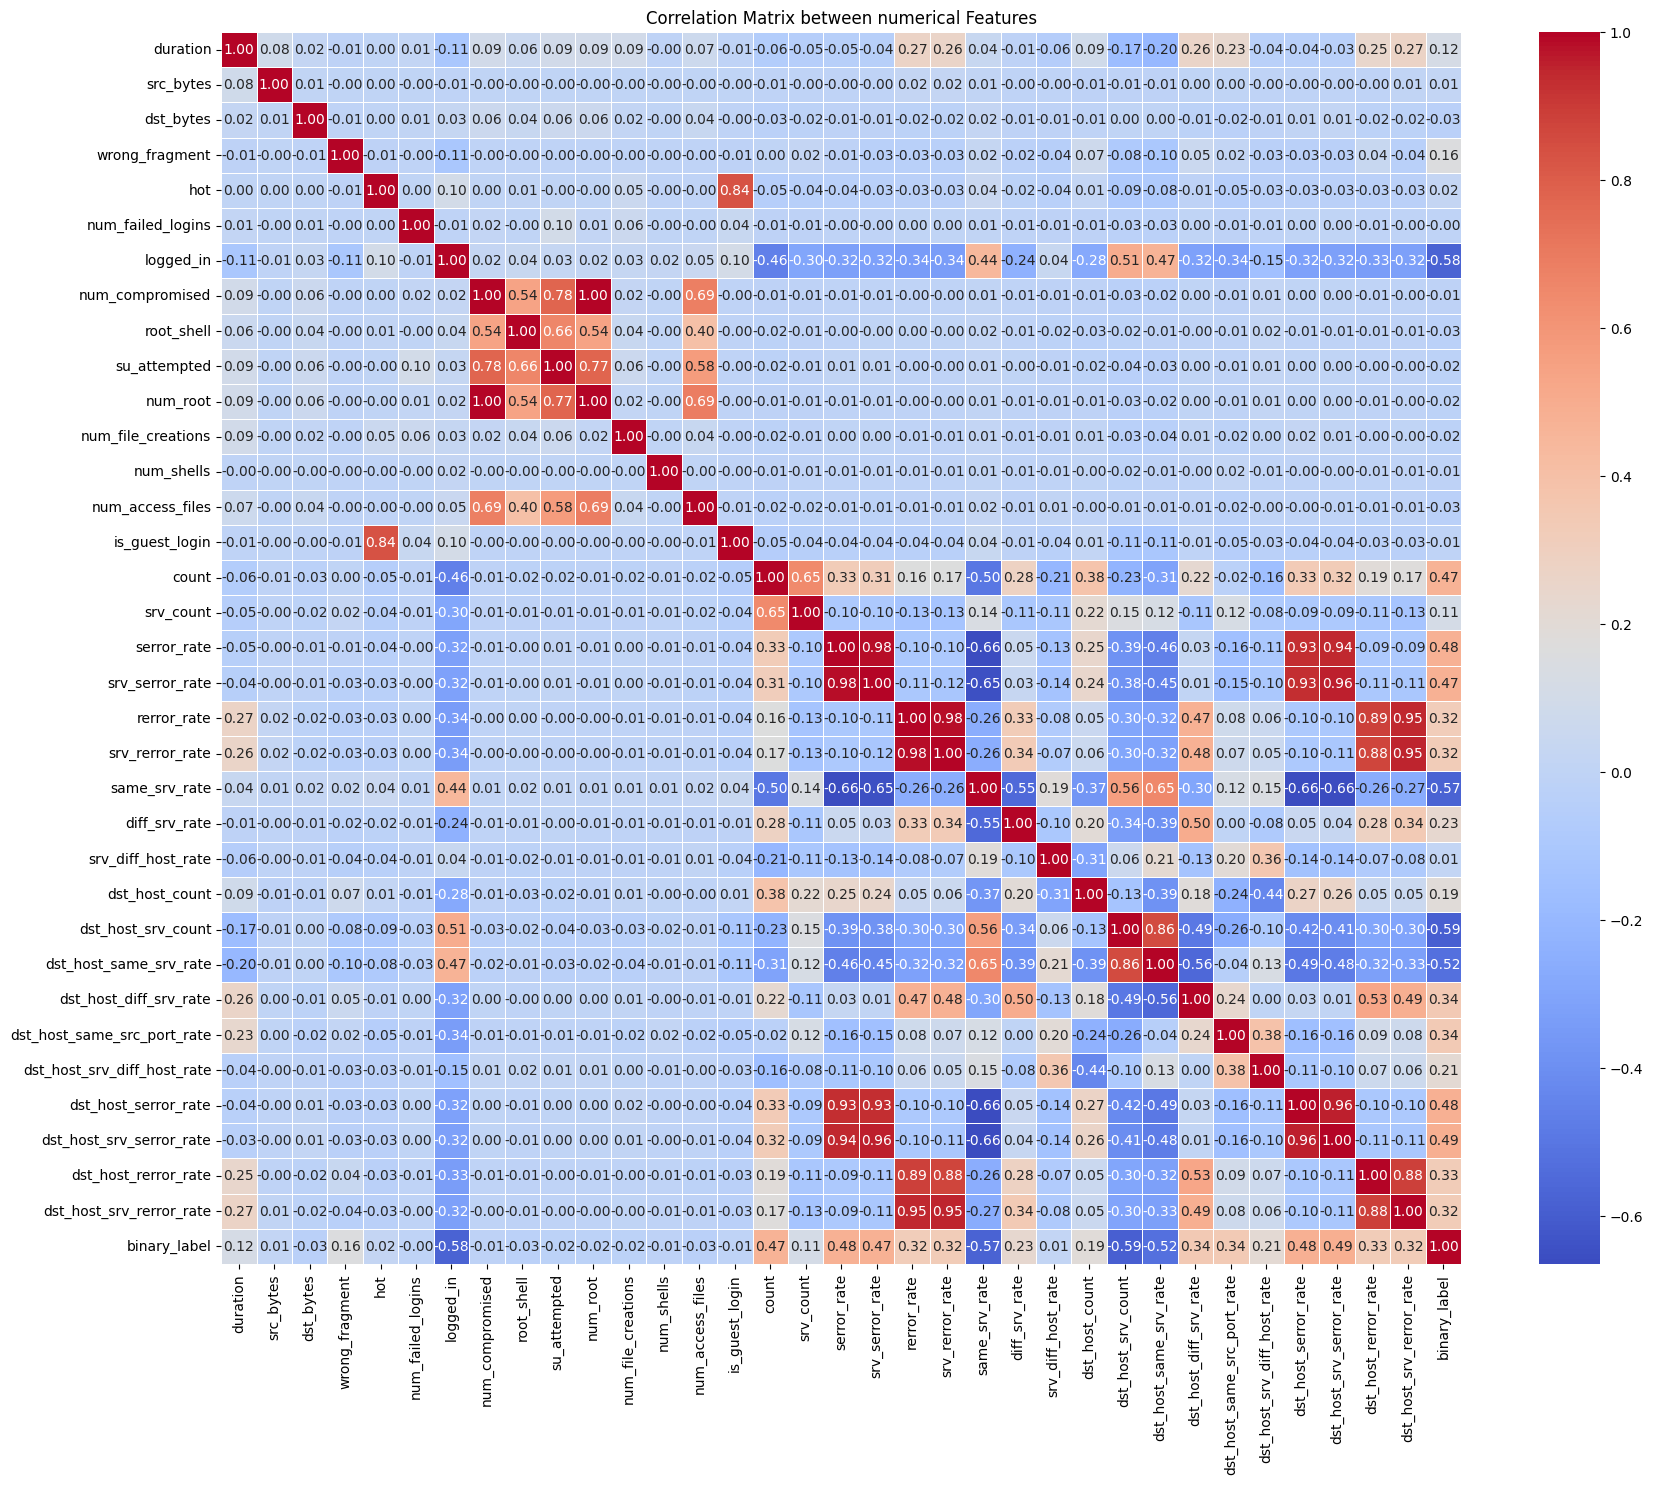

In [22]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = train_df.select_dtypes(include=np.number).columns
correlation_matrix = train_df[numeric_cols].corr()


plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix between numerical Features')
plt.show()

A clear block structure emerges:

Traffic counts – count and srv_count correlate ≈ 0.90, meaning they describe essentially the same burstiness in a 2-second window.

Error–rate twins – pairs like serror_rate ↔ srv_serror_rate, and rerror_rate ↔ srv_rerror_rate, reach ρ > 0.97; they are just host-level vs service-level versions of the same metric.

dst_host* family – all eight dst_host_*_rate features form a highly collinear cluster (many links ≥ 0.95).

same_srv_rate vs diff_srv_rate / srv_diff_host_rate – strong negative correlations (~ −0.97) because these rates sum (almost) to 1.

The target column binary_label never exceeds |ρ| ≈ 0.32 with any single feature: no “silver-bullet” predictor exists; the model must combine several signals.

In [23]:
import pandas as pd, numpy as np, scipy.stats as ss

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion)[0]
    n    = confusion.sum().sum()
    r,k  = confusion.shape
    return np.sqrt(chi2 / (n * (min(k, r)-1)))

cramers_v(train_df["protocol_type"], train_df["flag"])


np.float64(0.20706123200934412)

In [24]:
import pandas as pd, numpy as np, scipy.stats as ss

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion)[0]
    n    = confusion.sum().sum()
    r,k  = confusion.shape
    return np.sqrt(chi2 / (n * (min(k, r)-1)))

cramers_v(train_df["protocol_type"], train_df["service"])

np.float64(0.9323657614040991)

In [25]:
import pandas as pd, numpy as np, scipy.stats as ss

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion)[0]
    n    = confusion.sum().sum()
    r,k  = confusion.shape
    return np.sqrt(chi2 / (n * (min(k, r)-1)))

cramers_v(train_df["service"], train_df["flag"])

np.float64(0.2913226971855669)

| Pair                        | V        | Strength        | What it means in this dataset                                                                                                                                                                                               |
| --------------------------- | -------- | --------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `protocol_type` ↔ `service` | **0.93** | **Very strong** | Almost every service value is tied to a specific protocol family: e.g. `icmp` implies service =`ecr_i` / `eco_i`, `udp` implies `domain_u` / `tftp_u`, while most TCP services live under `tcp`. Hence the high redundancy. |
| `service` ↔ `flag`          | **0.29** | **Moderate**    | Certain TCP flags (e.g. `SF`, `S0`) appear disproportionately on a subset of services (web, ftp, etc.), but the relationship is far from deterministic.                                                                     |
| `protocol_type` ↔ `flag`    | **0.21** | **Weak**        | The distribution of flags (e.g. `SF`, `REJ`, `S0`) is only loosely influenced by the protocol; ICMP has a single pseudo-flag, whereas TCP/UDP share several, so the linkage is limited.                                     |


The V-scores confirm intuition: the port/service choice essentially determines the protocol, but flags remain a semi-independent signal.

- Explore the dataset: Before preprocessing the data, explore your data to understand
 the available features.

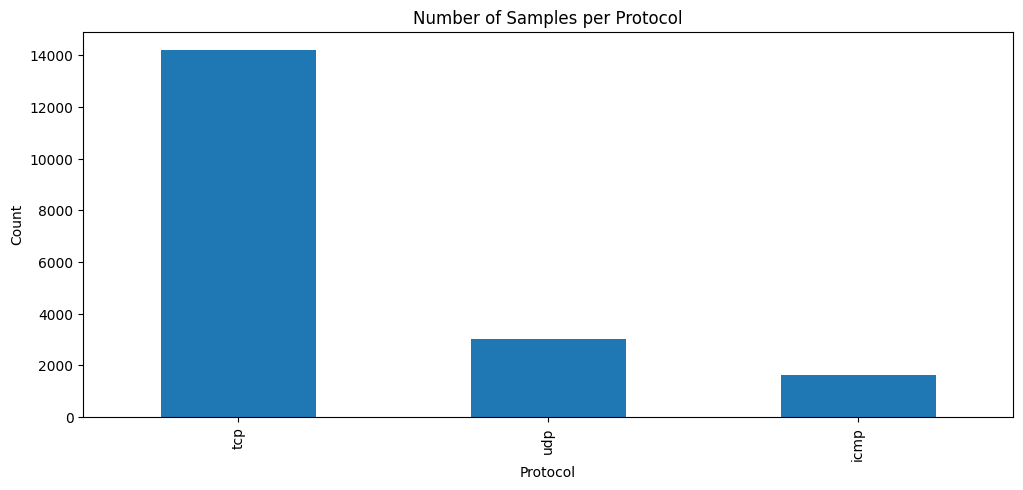

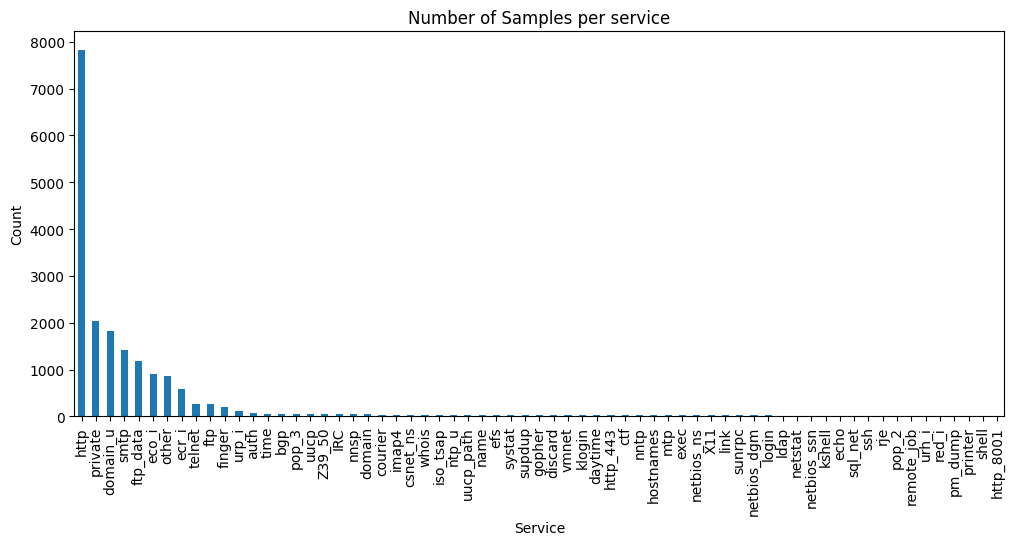

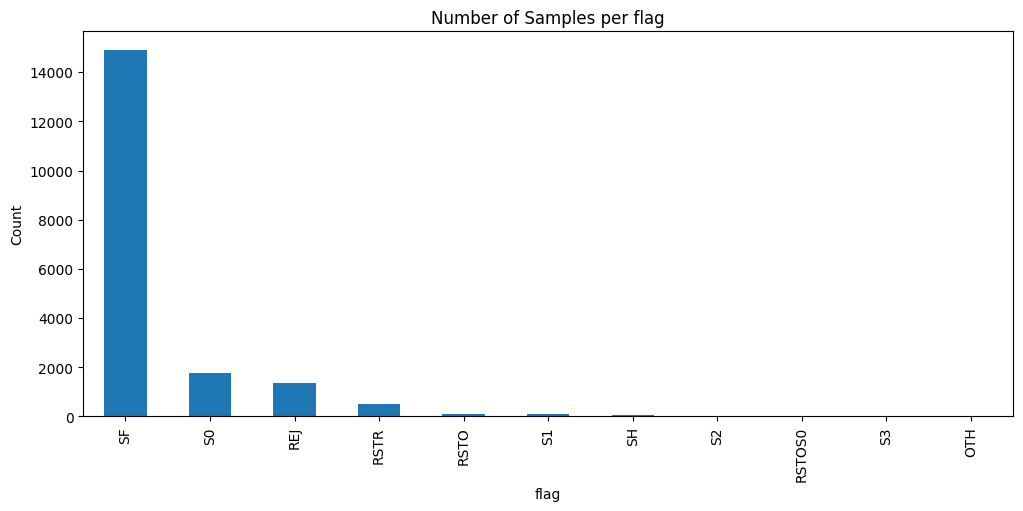

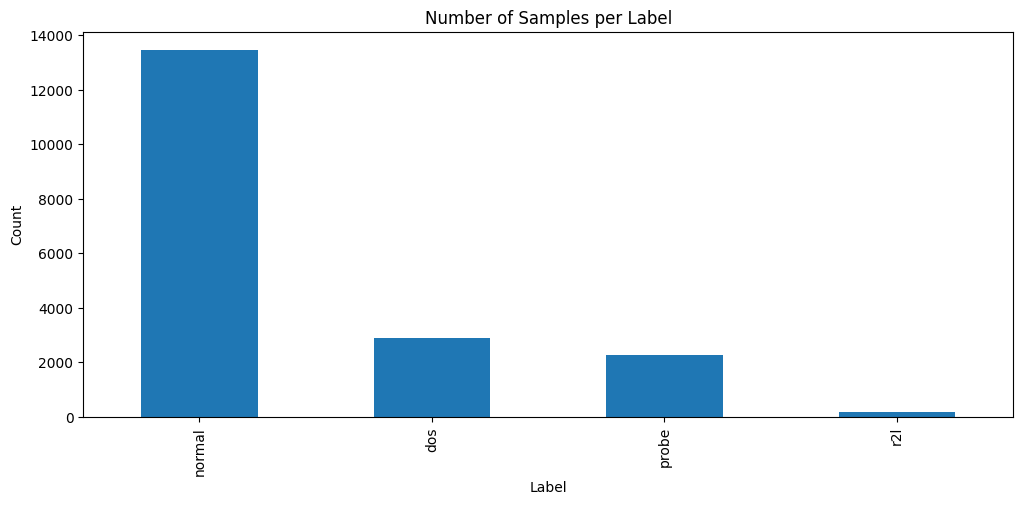

In [26]:
train_df["protocol_type"].value_counts().plot(kind="bar", figsize=(12, 5))
plt.title("Number of Samples per Protocol")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
plt.close()

train_df["service"].value_counts().plot(kind="bar", figsize=(12, 5))
plt.title("Number of Samples per service")
plt.xlabel("Service")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
plt.close()

train_df["flag"].value_counts().plot(kind="bar", figsize=(12, 5))
plt.title("Number of Samples per flag")
plt.xlabel("flag")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
plt.close()

train_df["label"].value_counts().plot(kind="bar", figsize=(12, 5))
plt.title("Number of Samples per Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
plt.close()

In [27]:
print(train_df["service"].value_counts()[:20])
print(train_df["flag"].value_counts()[:20])

service
http        7831
private     2036
domain_u    1820
smtp        1411
ftp_data    1191
eco_i        909
other        855
ecr_i        577
telnet       268
ftp          263
finger       193
urp_i        124
auth          75
time          59
bgp           43
pop_3         42
uucp          41
Z39_50        40
IRC           40
nnsp          40
Name: count, dtype: int64
flag
SF        14907
S0         1765
REJ        1359
RSTR        497
RSTO        112
S1           87
SH           42
S2           21
RSTOS0       21
S3           15
OTH           5
Name: count, dtype: int64


## stratify

In [28]:

#train_df, val_df = train_test_split(train_df, train_size=0.9, stratify=train_df["binary_label"],random_state=42)

df = train_df.copy()
df["strat_col"] = np.where(df["binary_label"] == 0, "normal", df["label"])

train_df, val_df = train_test_split(
        df,
        test_size   = 0.10,
        stratify    = df["strat_col"],
        random_state= 42
)

train_df.drop(columns="strat_col", inplace=True)
val_df.drop  (columns="strat_col", inplace=True)

In [29]:
# Define the allowed list of services
allowed_services = ["http", "private", "smtp", "domain_u", "other", "ftp_data", "ecr_i", "eco_i", "telnet", "finger", "ftp"]
# Apply the mapping WARNING we increase the diversity in in the "other" class
train_df["service"]  = train_df["service"].apply(lambda x: x if x in allowed_services else "other")
val_df["service"]    = val_df["service"].apply(lambda x: x if x in allowed_services else "other")
test_df["service"]   = test_df["service"].apply(lambda x: x if x in allowed_services else "other")

# Define the allowed list of services
allowed_flag = ["SF", "S0", "REJ", "RSTO"]
# Apply the mapping
train_df["flag"]  = train_df["flag"].apply(lambda x: x if x in allowed_flag else "other")
val_df["flag"]    = val_df["flag"].apply(lambda x: x if x in allowed_flag else "other")
test_df["flag"]   = test_df["flag"].apply(lambda x: x if x in allowed_flag else "other")

In [30]:
train_df["flag"].value_counts()[:20]

,count
flag,
SF,13403
S0,1593
REJ,1222
other,632
RSTO,97


In [31]:
train_df["service"].value_counts()[:20]

,count
service,
http,7053
other,2105
private,1832
domain_u,1621
smtp,1286
ftp_data,1063
eco_i,822
ecr_i,506
ftp,246


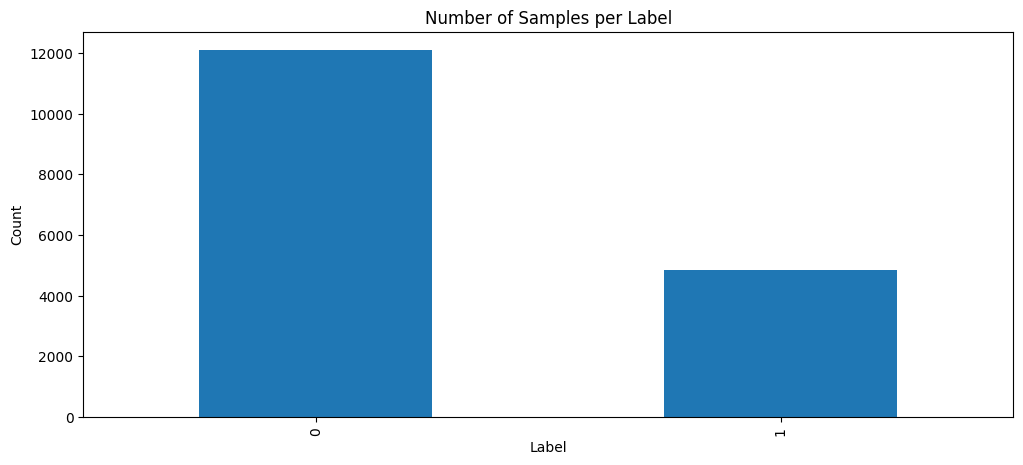

In [32]:
train_df["binary_label"].value_counts().plot(kind="bar", figsize=(12, 5))
plt.title("Number of Samples per Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
plt.close()

In [33]:
train_df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,hot,num_failed_logins,logged_in,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
7302,0,tcp,http,SF,146,3846,0,0,0,1,...,1.00,0.00,0.11,0.06,0.00,0.0,0.00,0.0,normal,0
16389,0,tcp,http,SF,325,1724,0,0,0,1,...,1.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,normal,0
8279,0,tcp,http,SF,307,1109,0,0,0,1,...,1.00,0.00,0.08,0.02,0.00,0.0,0.00,0.0,normal,0
17825,0,icmp,eco_i,SF,8,0,0,0,0,0,...,1.00,0.00,1.00,0.52,0.00,0.0,0.00,0.0,probe,1
20,0,tcp,http,SF,208,3867,0,0,0,1,...,1.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17047,0,tcp,other,REJ,0,0,0,0,0,0,...,0.00,1.00,0.00,0.00,0.27,0.0,0.73,1.0,probe,1
9174,8556,udp,other,SF,146,105,0,0,0,0,...,0.01,0.38,0.70,0.00,0.00,0.0,0.00,0.0,normal,0
4071,0,udp,domain_u,SF,46,86,0,0,0,0,...,1.00,0.00,0.01,0.00,0.00,0.0,0.00,0.0,normal,0
4439,0,tcp,http,SF,348,3804,0,0,0,1,...,1.00,0.00,0.50,0.04,0.00,0.0,0.00,0.0,normal,0


categorical features can be one hot encoded. categorical features are :'service', 'flag', 'protocol_type'

In [34]:
# Columns to one-hot encode
categorical_cols = ['service', 'flag', 'protocol_type']

# === 1. Fit encoder on training set ===
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(train_df[categorical_cols])

# === 2. Transform all splits ===
X_train_cat = encoder.transform(train_df[categorical_cols])
X_val_cat = encoder.transform(val_df[categorical_cols])
X_test_cat = encoder.transform(test_df[categorical_cols])

# === 3. Drop original categorical columns and concatenate encoded features ===
def replace_categorical(df, encoded, cols):
    df_numeric = df.drop(columns=cols).reset_index(drop=True)
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cols))
    return pd.concat([df_numeric.reset_index(drop=True), encoded_df], axis=1)

df_train_encoded = replace_categorical(train_df, X_train_cat, categorical_cols)
df_val_encoded = replace_categorical(val_df, X_val_cat, categorical_cols)
df_test_encoded = replace_categorical(test_df, X_test_cat, categorical_cols)

In [35]:
df_train_encoded

,duration,src_bytes,dst_bytes,wrong_fragment,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,...,service_smtp,service_telnet,flag_REJ,flag_RSTO,flag_S0,flag_SF,flag_other,protocol_type_icmp,protocol_type_tcp,protocol_type_udp
0,0,146,3846,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0,325,1724,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0,307,1109,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0,8,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0,208,3867,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16942,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16943,8556,146,105,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
16944,0,46,86,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
16945,0,348,3804,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [36]:
df_test_encoded

,duration,src_bytes,dst_bytes,wrong_fragment,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,...,service_smtp,service_telnet,flag_REJ,flag_RSTO,flag_S0,flag_SF,flag_other,protocol_type_icmp,protocol_type_tcp,protocol_type_udp
0,0,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0,55,51,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5821,0,46,85,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5822,0,45,45,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5823,0,44,79,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5824,0,54,52,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [37]:
#Perform feature normalization and process categorical and numerical features simultaneously

# === 1. Set up column groups ===
ignore_cols = ['label', 'binary_label']  # columns to skip entirely
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = [col for col in train_df.columns if col not in categorical_cols + ignore_cols]

# === 2. Define ColumnTransformer ===
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='drop'  # drop columns not listed (i.e., ignore_cols)
)

# === 3. Fit on training, transform all splits ===
X_train_transformed = preprocessor.fit_transform(train_df)
X_val_transformed   = preprocessor.transform(val_df)
X_test_transformed  = preprocessor.transform(test_df)

# === 4. Optional: Get transformed feature names and make DataFrames ===
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(cat_feature_names)

df_train_preprocessed = pd.DataFrame(X_train_transformed, columns=all_feature_names)
df_val_preprocessed   = pd.DataFrame(X_val_transformed, columns=all_feature_names)
df_test_preprocessed  = pd.DataFrame(X_test_transformed, columns=all_feature_names)



# === 5. Restore the labels ===
df_train_preprocessed["label"] = list(train_df["label"])
df_val_preprocessed["label"]   = list(val_df["label"])
df_test_preprocessed["label"]  = list(test_df["label"])

df_train_preprocessed["binary_label"] = list(train_df["binary_label"])
df_val_preprocessed["binary_label"]   = list(val_df["binary_label"])
df_test_preprocessed["binary_label"]  = list(test_df["binary_label"])

In [38]:
def plot_pca(df):

    # -----------------------------
    # 1. EXPLAINED VARIANCE PLOT
    # -----------------------------

    # Fit PCA with all components
    pca_full = PCA().fit(df.drop(columns=['label','binary_label']))

    # Plot explained variance ratio
    plt.figure(figsize=(8, 5))

    x = [i+1 for i in range(len(pca_full.explained_variance_ratio_))]
    y = np.cumsum(pca_full.explained_variance_ratio_)
    plt.plot(x,y, marker='o')
    plt.title('Cumulative Explained Variance by PCA Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.xlim(1,len(pca_full.explained_variance_ratio_))
    plt.grid(True)
    plt.show()
    plt.close()

    # -----------------------------
    # 2. KDE PLOT IN 2D
    # -----------------------------

    # Apply PCA to reduce to 2 components for KDE visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(df.drop(columns=['label','binary_label']))
    labels = list(df['binary_label'])

    df_kde = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_kde['label'] = labels

    sns.scatterplot(data=df_kde, x='PC1', y='PC2', hue='label', palette='Set1')
    plt.title('Scatterplot Colored by Label')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(title='Label')
    plt.show()
    plt.close()

    return


def plot_tsne(df):

    # -----------------------------
    # 3. t-SNE PLOT
    # -----------------------------

    # Run t-SNE on the features (you can apply PCA first for speed if needed)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(df.drop(columns=['label','binary_label']))
    labels = list(df['binary_label'])

    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    df_tsne['label'] = labels

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_tsne, x='TSNE1', y='TSNE2',
        hue='label', palette='Set1', alpha=0.8
    )
    plt.title('2D t-SNE Projection')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(title='Label')
    plt.show()

    return

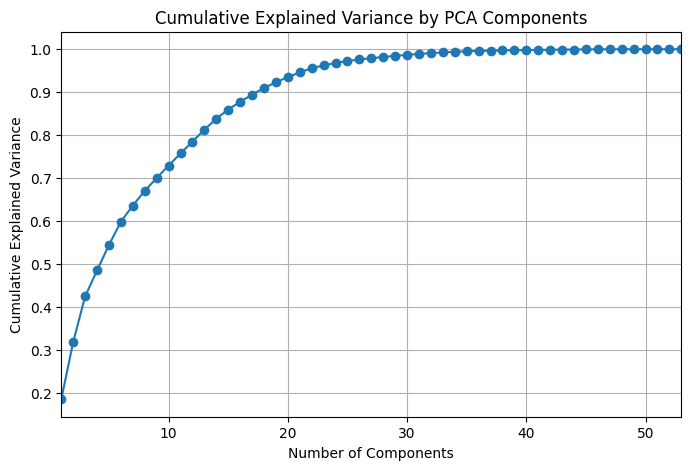

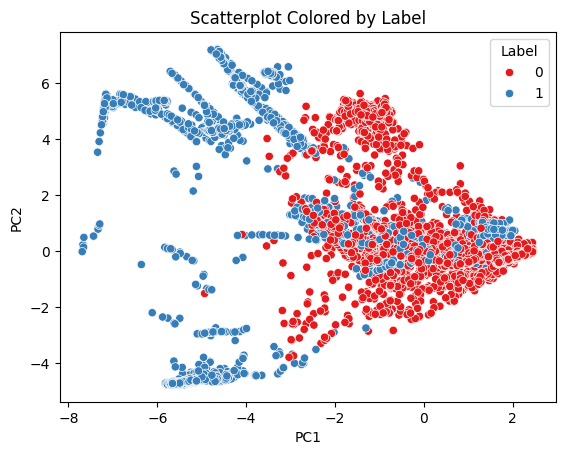

In [39]:
plot_pca(df_train_preprocessed)

| What we plotted               | Key observation                                                                                                                                                                                                                                                            | Why it matters                                                                                                                                                                                                                                        |
| ----------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **PCA – cumulative variance** | \~15 components already capture ≈ 85 % of the total variance, 20 reach ≈ 93 %, and 25–30 push us past 97 %.                                                                                                                                                                | We can safely trim the feature space by a factor 2-3 without losing much information – useful for faster training or as a preprocessing step for distance-based detectors.                                                                            |
| **PCA scatter (PC1 × PC2)**   | The first two axes (\~30 % of variance) show a **coarse, mostly linear band** where attack samples (blue) occupy the left/upper lobes and normal traffic (red) crowds the right/central area.  Still, there is visible overlap → pure linear separation will leave errors. | Confirms that some attack types differ along the strongest variability directions, yet additional (non-linear) information is needed for clean discrimination.                                                                                        |



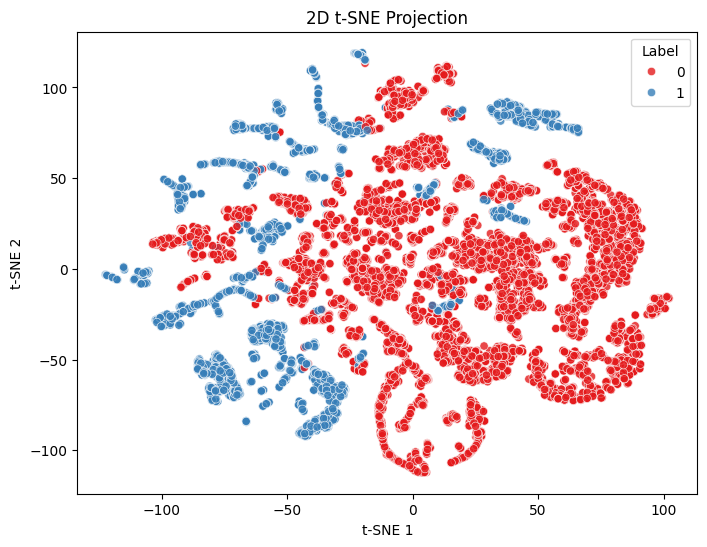

In [40]:

plot_tsne(df_train_preprocessed)


| **t-SNE 2-D map**             |

With a purely non-linear embedding the two classes form **well-defined islands**.  One large red cluster (normal), two compact blue regions (DoS / Probe style attacks), and many small mixed pockets.                                                                     | Supports the idea of **multi-cluster anomaly detection**: attacks are not a single blob but several phenotypes.  Also suggests that a kernel-based or tree ensemble model can exploit these complex frontiers better than a plain logistic/PCA combo. |


In [41]:
from sklearn.decomposition import PCA
from sklearn.manifold     import TSNE
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pca(df, keep_cols=20):
    X = df.drop(columns=['label', 'binary_label'])

    # -------------------------------------------------
    # 1. cumulative explained variance (full PCA)
    # -------------------------------------------------
    pca_full = PCA().fit(X)
    plt.figure(figsize=(8, 5))
    x = np.arange(1, len(pca_full.explained_variance_ratio_) + 1)
    y = np.cumsum(pca_full.explained_variance_ratio_)
    plt.plot(x, y, marker='o')
    plt.title('Cumulative Explained Variance by PCA Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show(); plt.close()

    # -------------------------------------------------
    # 2. keep-N projection (here N = 20)
    # -------------------------------------------------
    pca_20     = PCA(n_components=keep_cols, random_state=42)
    X_pca20    = pca_20.fit_transform(X)          # shape: (n_rows, 20)
    df_pca20   = pd.DataFrame(X_pca20,
                              columns=[f'PC{i+1}' for i in range(keep_cols)])
    df_pca20['label']        = df['label'].values
    df_pca20['binary_label'] = df['binary_label'].values
    # >>>  you can now save df_pca20 or pass it to your classifier <<<

    # -------------------------------------------------
    # 3. 2-D scatter using the first two PCs
    # -------------------------------------------------
    pca2 = PCA(n_components=2, random_state=42)
    X_pca2 = pca2.fit_transform(X)
    df_plot = pd.DataFrame(X_pca2, columns=['PC1', 'PC2'])
    df_plot['binary_label'] = df['binary_label'].values

    sns.scatterplot(data=df_plot, x='PC1', y='PC2',
                    hue='binary_label', palette='Set1')
    plt.title('Scatterplot Colored by Label')
    plt.legend(title='Label')
    plt.show(); plt.close()

    return df_pca20        # <- 20-component dataframe

def plot_tsne(df):
    X   = df.drop(columns=['label','binary_label'])
    y   = df['binary_label'].values

    # optional speed-up: first reduce to 20 PCs, then run t-SNE
    X_reduced = PCA(n_components=20, random_state=42).fit_transform(X)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_reduced)

    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    df_tsne['binary_label'] = y

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2',
                    hue='binary_label', palette='Set1', alpha=0.8)
    plt.title('2D t-SNE Projection')
    plt.legend(title='Label')
    plt.show()


In [42]:
res = df_train_preprocessed.value_counts("binary_label")
anomaly_rate = res[1]/(res[0]+res[1])
print("The fraction of anomalies in the dataset is %.2f"%anomaly_rate)

The fraction of anomalies in the dataset is 0.29


In [43]:
# Display basic info
print("Initial shape:", df_train_preprocessed.shape)

# 2. Data Cleaning
# Drop duplicate rows
df_train_preprocessed.drop_duplicates(inplace=True)

# Display basic info
print("final shape:", df_train_preprocessed.shape)

Initial shape: (16947, 55)
final shape: (16917, 55)


In [44]:
# Display basic info
print("Initial shape:", df_test_preprocessed.shape)

# 2. Data Cleaning
# Drop duplicate rows
df_test_preprocessed.drop_duplicates(inplace=True)

# Display basic info
print("final shape:", df_test_preprocessed.shape)

Initial shape: (5826, 55)
final shape: (5771, 55)


In [45]:
df_train_normal_only = df_train_preprocessed[df_train_preprocessed["binary_label"]==0].copy()
X_train_normal_only = df_train_normal_only.drop(columns=['label', 'binary_label'])
y_train_normal_only = list(df_train_normal_only['binary_label'])

X_train = df_train_preprocessed.drop(columns=['label', 'binary_label'])
y_original_train = list(df_train_preprocessed['label'])
y_train = list(df_train_preprocessed['binary_label'])

X_val = df_val_preprocessed.drop(columns=['label', 'binary_label'])
y_original_val = list(df_val_preprocessed['label'])
y_val = list(df_val_preprocessed['binary_label'])

X_test = df_test_preprocessed.drop(columns=['label', 'binary_label'])
y_original_test = list(df_test_preprocessed['label'])
y_test = list(df_test_preprocessed['binary_label'])

In [46]:
import torch

# 1) Data normal only
X_train_normal_only_tensor = torch.tensor(
    X_train_normal_only.values, dtype=torch.float32
)
y_train_normal_only_tensor = torch.tensor(
    y_train_normal_only, dtype=torch.float32
) # shape (N,1) per la BCE loss

# 2) Full training set
X_train_tensor = torch.tensor(
    X_train.values, dtype=torch.float32
)
y_train_tensor = torch.tensor(
    y_train, dtype=torch.float32
)

# 3) Validation set
X_val_tensor = torch.tensor(
    X_val.values, dtype=torch.float32
)
y_val_tensor = torch.tensor(
    y_val, dtype=torch.float32
)

# 4) Test set
X_test_tensor = torch.tensor(
    X_test.values, dtype=torch.float32
)
y_test_tensor = torch.tensor(
    y_test, dtype=torch.float32
)


In [47]:
def plot_confusion_matrix(y_binary, y_pred, methodology, data_name):

    print("\nClassification Report (%s vs Ground Truth):", methodology)
    print(classification_report(y_binary, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_binary, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'])
    plt.title('Confusion Matrix %s with %s'%(data_name,methodology))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    plt.close()

Studying data from a domain expert perspective

As such plot and report the following 3 heatmaps:

– Mean heatmap

– Standard Deviation heatmap

– Median Heatmap

In [48]:
df_train_preprocessed

,duration,src_bytes,dst_bytes,wrong_fragment,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,...,service_private,service_smtp,service_telnet,flag_REJ,flag_RSTO,flag_S0,flag_SF,flag_other,label,binary_label
0,-0.131952,-0.011877,0.008692,-0.10023,-0.107641,-0.0228,0.944031,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,0
1,-0.131952,-0.011816,-0.025972,-0.10023,-0.107641,-0.0228,0.944031,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,0
2,-0.131952,-0.011822,-0.036018,-0.10023,-0.107641,-0.0228,0.944031,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,0
3,-0.131952,-0.011924,-0.054134,-0.10023,-0.107641,-0.0228,-1.059287,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,probe,1
4,-0.131952,-0.011856,0.009036,-0.10023,-0.107641,-0.0228,0.944031,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16942,-0.131952,-0.011927,-0.054134,-0.10023,-0.107641,-0.0228,-1.059287,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,probe,1
16943,2.613168,-0.011877,-0.052419,-0.10023,-0.107641,-0.0228,-1.059287,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,0
16944,-0.131952,-0.011911,-0.052729,-0.10023,-0.107641,-0.0228,-1.059287,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,0
16945,-0.131952,-0.011809,0.008006,-0.10023,-0.107641,-0.0228,0.944031,-0.026136,-0.040681,-0.03302,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,0


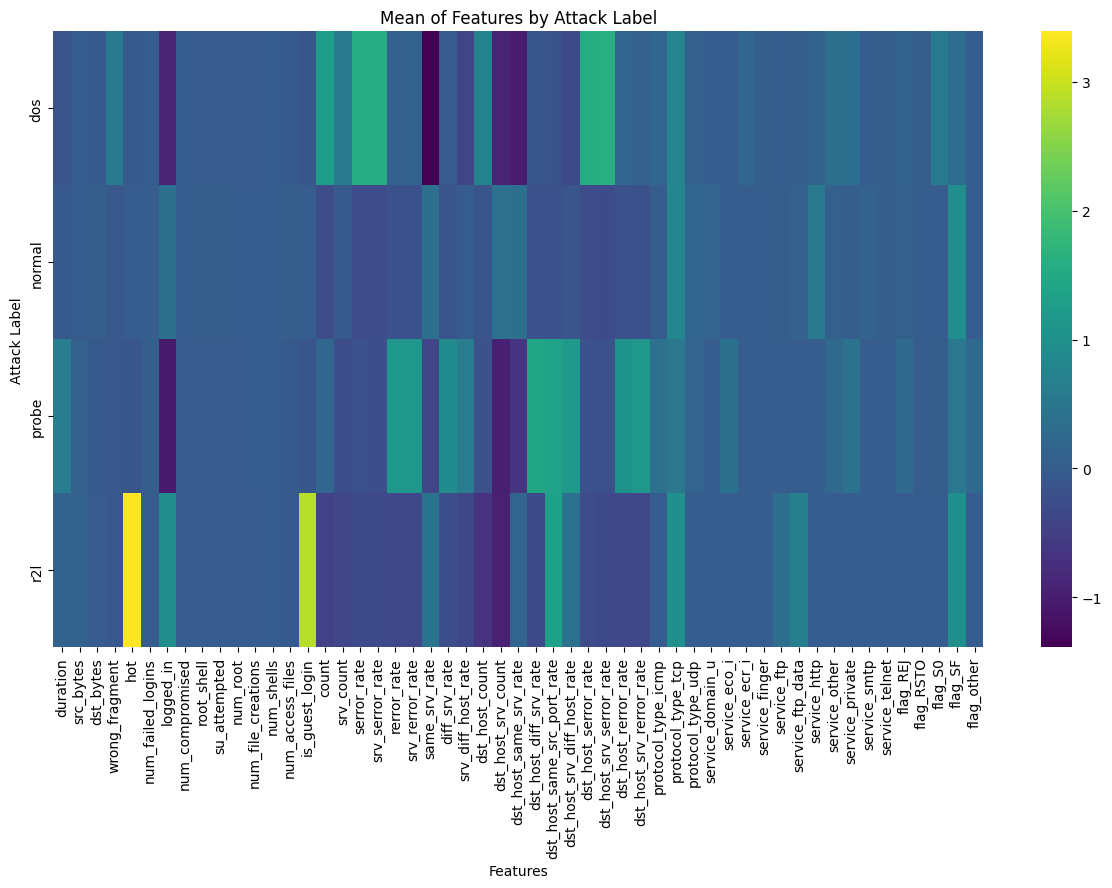

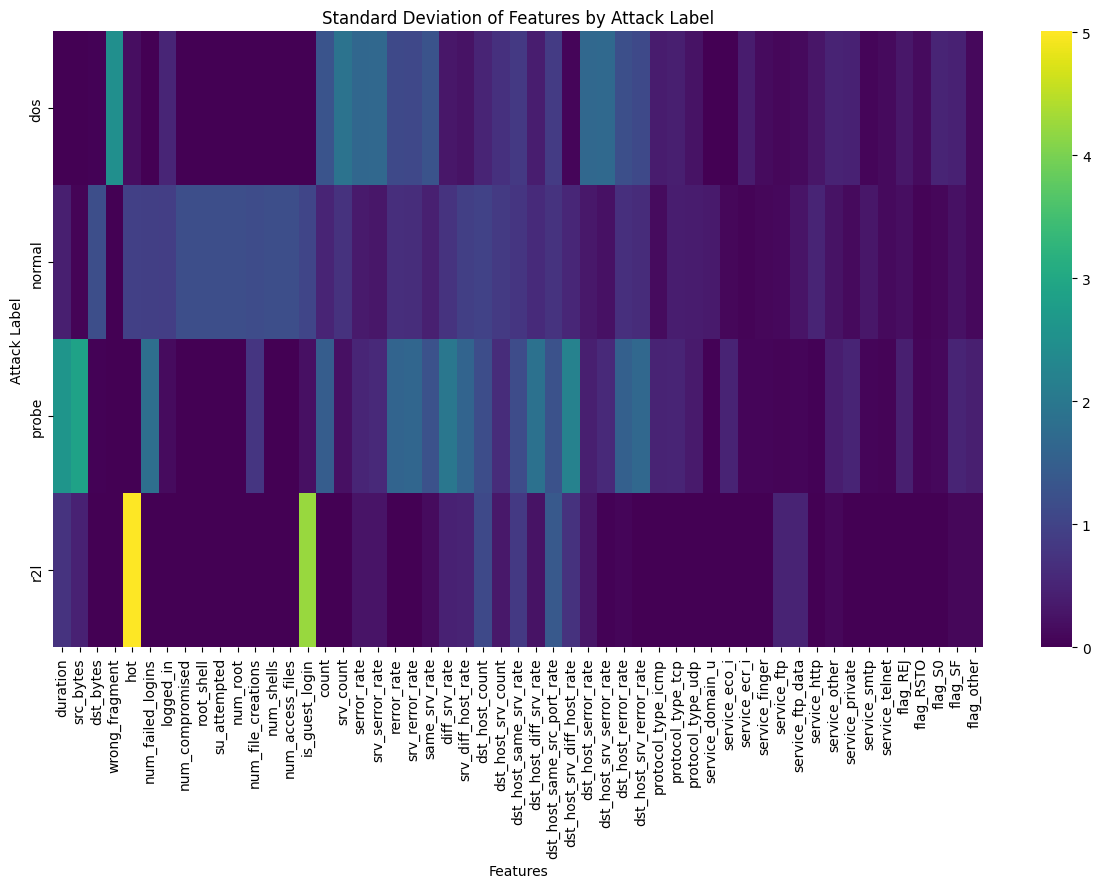

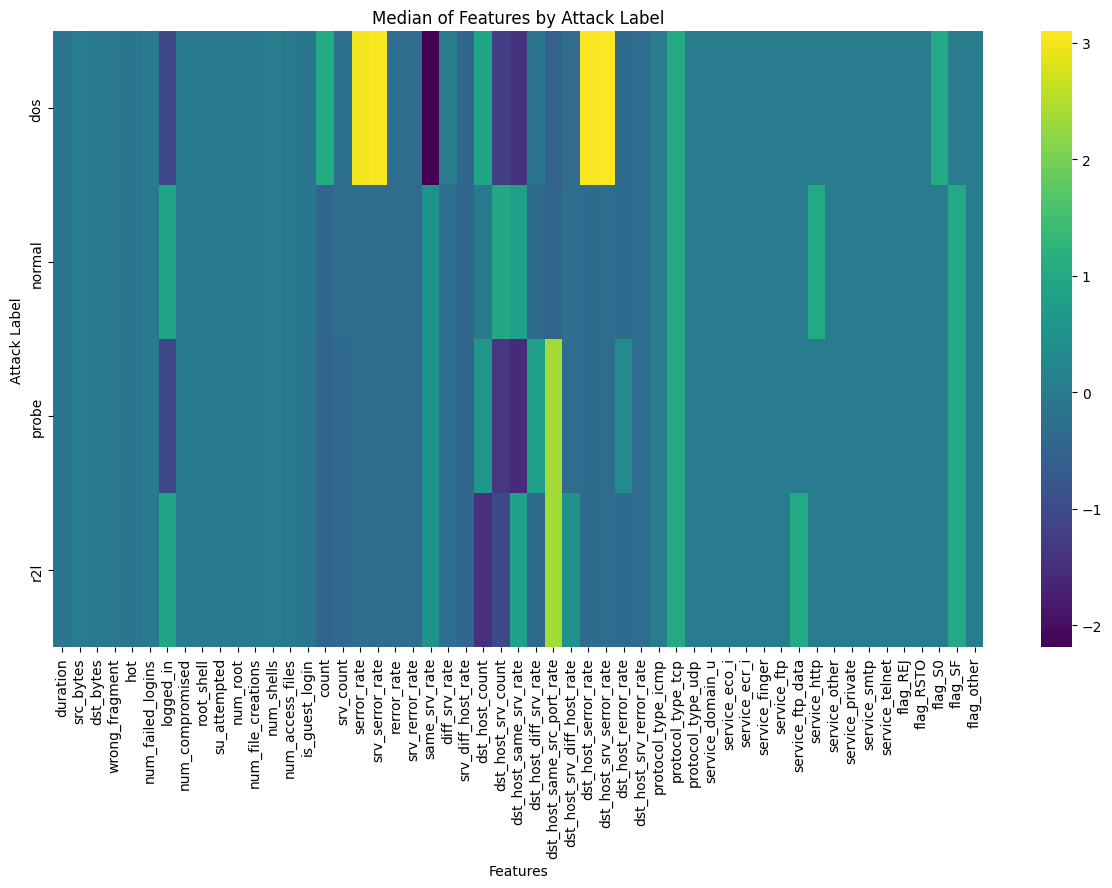

In [49]:
import matplotlib.pyplot as plt
# Group by label and calculate mean
mean_by_label = df_train_preprocessed.groupby('label').mean()

# Drop the 'binary_label' column if it exists, as we grouped by the granular 'label'
if 'binary_label' in mean_by_label.columns:
  mean_by_label = mean_by_label.drop(columns=['binary_label'])

# Plot the Mean heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(mean_by_label, annot=False, cmap='viridis')
plt.title('Mean of Features by Attack Label')
plt.xlabel('Features')
plt.ylabel('Attack Label')
plt.show()
plt.close()

# Group by label and calculate standard deviation
std_by_label = df_train_preprocessed.groupby('label').std()

# Drop the 'binary_label' column if it exists
if 'binary_label' in std_by_label.columns:
  std_by_label = std_by_label.drop(columns=['binary_label'])

# Plot the Standard Deviation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(std_by_label, annot=False, cmap='viridis')
plt.title('Standard Deviation of Features by Attack Label')
plt.xlabel('Features')
plt.ylabel('Attack Label')
plt.show()
plt.close()

# Group by label and calculate median
median_by_label = df_train_preprocessed.groupby('label').median()

# Drop the 'binary_label' column if it exists
if 'binary_label' in median_by_label.columns:
  median_by_label = median_by_label.drop(columns=['binary_label'])

# Plot the Median heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(median_by_label, annot=False, cmap='viridis')
plt.title('Median of Features by Attack Label')
plt.xlabel('Features')
plt.ylabel('Attack Label')
plt.show()
plt.close()

| Attack type | Bright strips in **MEAN** / **MEDIAN** map | Why these features light up |
|-------------|-------------------------------------------|-----------------------------|
| **DoS** | `serror_rate`, `srv_serror_rate`, `dst_host_serror_rate`, `dst_host_srv_serror_rate` all ≈ 1 &nbsp;•&nbsp; `count`, `srv_count` well above the other classes | A SYN-flood sends a burst of half-open connections that never complete the three-way handshake.  The result is a *service- and host-level SYN error rate of ~100 %* and an abnormally large number of connections in the last 2 s window. |
| **Probe / Scan** | `rerror_rate`, `srv_rerror_rate`, `dst_host_rerror_rate`, `dst_host_srv_rerror_rate` &nbsp;•&nbsp; `diff_srv_rate`, `srv_diff_host_rate` &nbsp;•&nbsp; high variance in `src_bytes` | A port scanner keeps hitting **closed ports**, so the remote host replies with RST packets → high **R-error rates**.  Scans also touch many different services/hosts, raising the “different-service” rates. |
| **R2L** | Spikes in `hot`, `num_failed_logins`, `num_access_files`, `root_shell`, `su_attempted` | Remote-to-local attacks try to **guess passwords or exploit application payloads**.  They show multiple failed logins, abnormal file accesses, and occasionally spawn a root shell—precisely the “hot” indicators engineered in the KDD dataset. |
| **Normal** | `same_srv_rate` and `dst_host_same_srv_rate` near 1; all error-rates near 0 | Legitimate traffic tends to reuse the same service and completes the TCP handshake without errors. |

The **standard-deviation map** supports this reading:  
* DoS and Probe rows have the highest σ for byte counts and connection rates (bursty behaviour).  
* R2L’s σ is essentially zero on most fields—those attacks are few but very deterministic when they occur.

---




#  Task 2: Shallow Anomaly Detection- Supervised vs Unsupervised

## One-Class SVM with Normal data only

In [50]:
### Anomaly Detection using SVM input data with normal data only - kind of "supervised"

 ### - default value of nu

In [51]:
# === 1. Fit One-Class SVM ===
# Assume X_train is your input data (numpy array or DataFrame with features only)
ocsvm_normal_only = OneClassSVM(kernel='rbf', gamma='scale', nu=0.001)  # nu = expected anomaly proportion - only normal data
ocsvm_normal_only.fit(X_train_normal_only)

OneClassSVM(nu=0.001)

In [52]:
# === 2. Inference ===
# Predict returns 1 for inliers, -1 for outliers
# Convert to binary anomaly labels: 1 = anomaly, 0 = normal

y_train_pred = ocsvm_normal_only.predict(X_train)
y_train_pred_binary = (y_train_pred == -1).astype(int)


y_val_pred = ocsvm_normal_only.predict(X_val)
y_val_pred_binary = (y_val_pred == -1).astype(int)

y_test_pred = ocsvm_normal_only.predict(X_test)
y_test_pred_binary = (y_test_pred == -1).astype(int)


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     12102
           1       0.98      0.76      0.86      4815

    accuracy                           0.93     16917
   macro avg       0.95      0.88      0.90     16917
weighted avg       0.93      0.93      0.92     16917



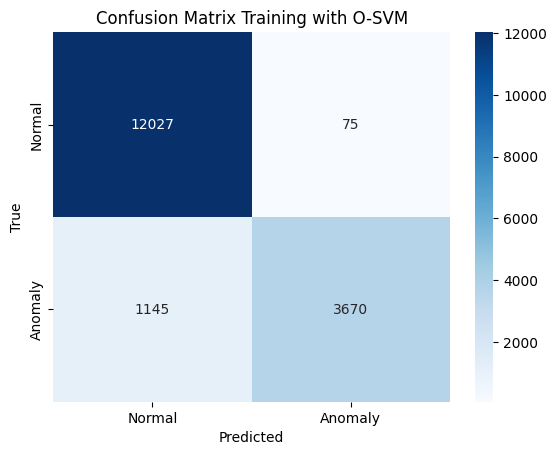


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1346
           1       0.96      0.72      0.82       538

    accuracy                           0.91      1884
   macro avg       0.93      0.85      0.88      1884
weighted avg       0.92      0.91      0.91      1884



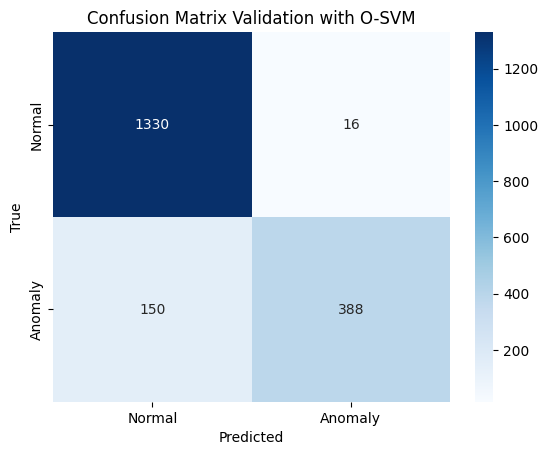


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.63      0.75      0.69      2152
           1       0.83      0.74      0.78      3619

    accuracy                           0.74      5771
   macro avg       0.73      0.74      0.73      5771
weighted avg       0.76      0.74      0.75      5771



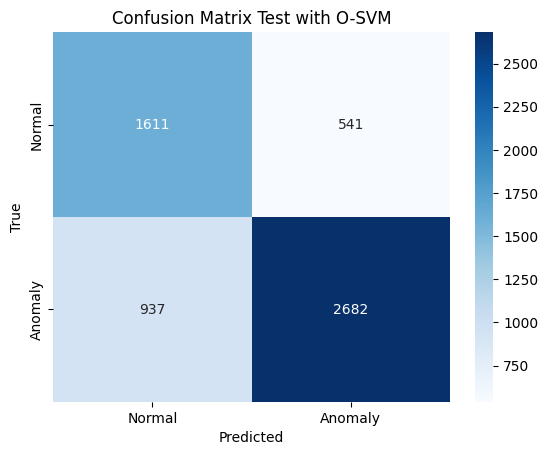

In [53]:
plot_confusion_matrix(y_train, y_train_pred_binary, "O-SVM", "Training")
plot_confusion_matrix(y_val, y_val_pred_binary, "O-SVM", "Validation")
plot_confusion_matrix(y_test, y_test_pred_binary, "O-SVM", "Test")

In [54]:
# === 3. Anomaly score (distance from separating hyperplane) ===
anomaly_scores = ocsvm_normal_only.decision_function(X_val)  # the higher, the more normal
# We may use it to investigate the anomalies

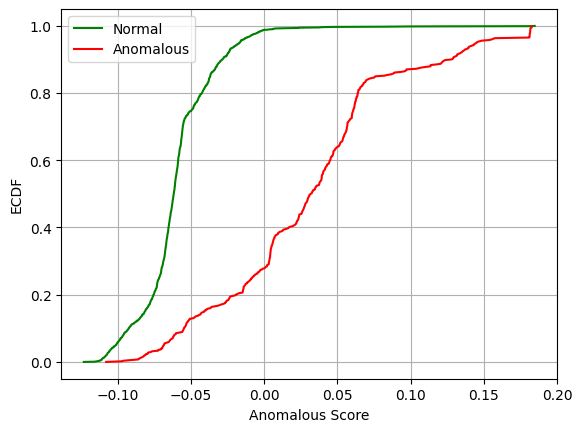

In [55]:
anomalous_points_scores = anomaly_scores[np.array(y_val) == 1]
normal_points_scores = anomaly_scores[np.array(y_val) == 0]
plt.plot(sorted(-normal_points_scores), [i/len(normal_points_scores) for i in range(len(normal_points_scores))], label = "Normal", c="green")
plt.plot(sorted(-anomalous_points_scores),[i/len(anomalous_points_scores) for i in range(len(anomalous_points_scores))], label = "Anomalous", c="red")
plt.legend()
plt.grid()
plt.xlabel("Anomalous Score")
plt.ylabel("ECDF")
plt.show()

### - estimated nu

In [56]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, roc_auc_score

nu_grid     = [0.0005, 0.001, 0.002, 0.005, 0.01]          # 0.05 % – 1 %
gamma_grid  = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, "scale"]
best_f1, best_pars = 0, None

for pars in ParameterGrid({'nu':nu_grid, 'gamma':gamma_grid}):
    oc = OneClassSVM(kernel='rbf', **pars).fit(X_train_normal_only)

    # predict on validation set (contains normals + attacks)
    y_val_pred = (oc.predict(X_val) == -1).astype(int)
    f1 = f1_score(y_val, y_val_pred)

    if f1 > best_f1:
        best_f1, best_pars = f1, pars

print("Best params:", best_pars, "F1:", best_f1)


Best params: {'gamma': 0.1, 'nu': 0.005} F1: 0.8952929875120077


In [57]:
# === 1. Fit One-Class SVM ===
# Assume X_train is your input data (numpy array or DataFrame with features only)
ocsvm_normal_only = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.005)  # nu = expected anomaly proportion - only normal data
ocsvm_normal_only.fit(X_train_normal_only)

OneClassSVM(gamma=0.1, nu=0.005)

In [58]:
# === 2. Inference ===
# Predict returns 1 for inliers, -1 for outliers
# Convert to binary anomaly labels: 1 = anomaly, 0 = normal

y_train_pred = ocsvm_normal_only.predict(X_train)
y_train_pred_binary = (y_train_pred == -1).astype(int)


y_val_pred = ocsvm_normal_only.predict(X_val)
y_val_pred_binary = (y_val_pred == -1).astype(int)

y_test_pred = ocsvm_normal_only.predict(X_test)
y_test_pred_binary = (y_test_pred == -1).astype(int)


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     12102
           1       0.96      0.87      0.91      4815

    accuracy                           0.95     16917
   macro avg       0.96      0.93      0.94     16917
weighted avg       0.95      0.95      0.95     16917



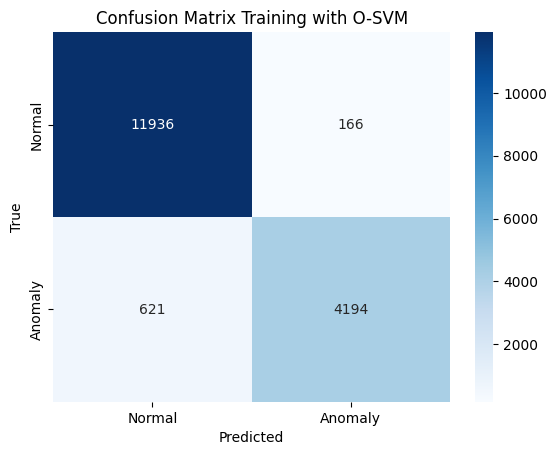


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1346
           1       0.93      0.87      0.90       538

    accuracy                           0.94      1884
   macro avg       0.94      0.92      0.93      1884
weighted avg       0.94      0.94      0.94      1884



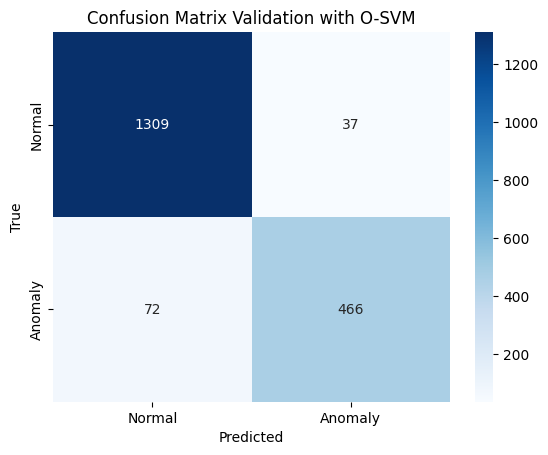


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.75      0.64      0.69      2152
           1       0.80      0.87      0.84      3619

    accuracy                           0.79      5771
   macro avg       0.78      0.76      0.76      5771
weighted avg       0.78      0.79      0.78      5771



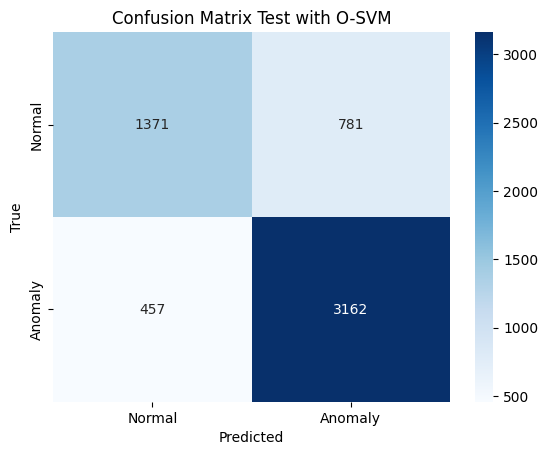

In [59]:
plot_confusion_matrix(y_train, y_train_pred_binary, "O-SVM", "Training")
plot_confusion_matrix(y_val, y_val_pred_binary, "O-SVM", "Validation")
plot_confusion_matrix(y_test, y_test_pred_binary, "O-SVM", "Test")

In [60]:
# === 3. Anomaly score (distance from separating hyperplane) ===
anomaly_scores = ocsvm_normal_only.decision_function(X_val)  # the higher, the more normal
# We may use it to investigate the anomalies

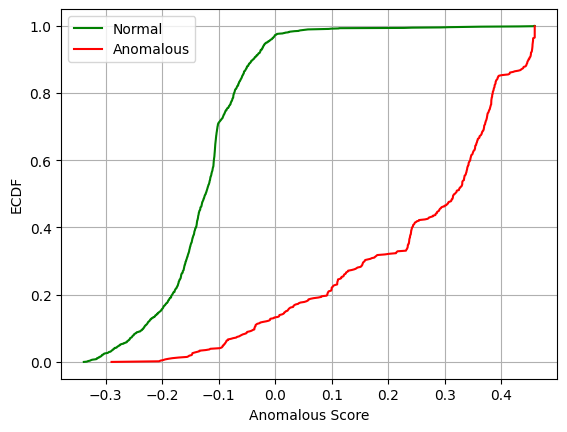

In [61]:
anomalous_points_scores = anomaly_scores[np.array(y_val) == 1]
normal_points_scores = anomaly_scores[np.array(y_val) == 0]
plt.plot(sorted(-normal_points_scores), [i/len(normal_points_scores) for i in range(len(normal_points_scores))], label = "Normal", c="green")
plt.plot(sorted(-anomalous_points_scores),[i/len(anomalous_points_scores) for i in range(len(anomalous_points_scores))], label = "Anomalous", c="red")
plt.legend()
plt.grid()
plt.xlabel("Anomalous Score")
plt.ylabel("ECDF")
plt.show()

## One-Class SVM with All data

In [62]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, roc_auc_score

nu_grid     = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.29, 0.33, 0.20, 0.25, 0.30, 0.35, 0.40]          # 0.05 % – 33 %
gamma_grid  = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, "scale"]
best_f1, best_pars = 0, None

for pars in ParameterGrid({'nu':nu_grid, 'gamma':gamma_grid}):
    oc = OneClassSVM(kernel='rbf', **pars).fit(X_train)

    # predict on validation set (contains normals + attacks)
    y_val_pred = (oc.predict(X_val) == -1).astype(int)
    f1 = f1_score(y_val, y_val_pred)          # or roc_auc_score

    if f1 > best_f1:
        best_f1, best_pars = f1, pars

print("Best params:", best_pars, "F1:", best_f1)


Best params: {'gamma': 0.0001, 'nu': 0.3} F1: 0.7678244972577697


Global anomaly share in training data: 29.000%
Best ν,γ on *contaminated* training: {'nu': 0.3, 'gamma': 0.0001}  →  F1=0.836

Classification Report (%s vs Ground Truth): OC-SVM (mixed training)
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     12102
           1       0.76      0.80      0.78      4815

    accuracy                           0.87     16917
   macro avg       0.84      0.85      0.85     16917
weighted avg       0.88      0.87      0.87     16917



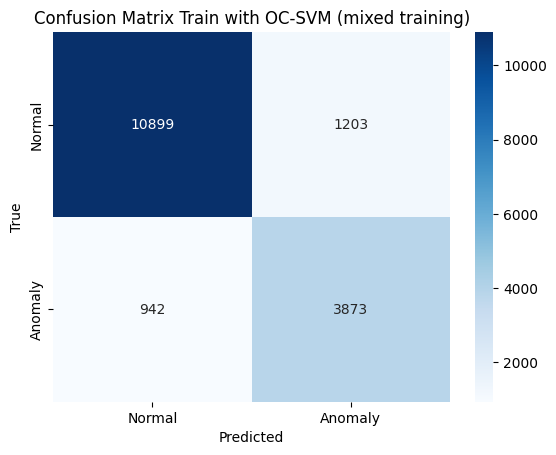


Classification Report (%s vs Ground Truth): OC-SVM (mixed training)
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1346
           1       0.76      0.78      0.77       538

    accuracy                           0.87      1884
   macro avg       0.83      0.84      0.84      1884
weighted avg       0.87      0.87      0.87      1884



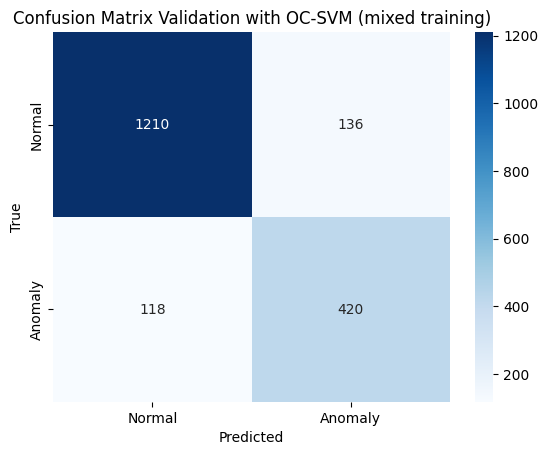


Classification Report (%s vs Ground Truth): OC-SVM (mixed training)
              precision    recall  f1-score   support

           0       0.65      0.67      0.66      2152
           1       0.80      0.78      0.79      3619

    accuracy                           0.74      5771
   macro avg       0.72      0.73      0.73      5771
weighted avg       0.74      0.74      0.74      5771



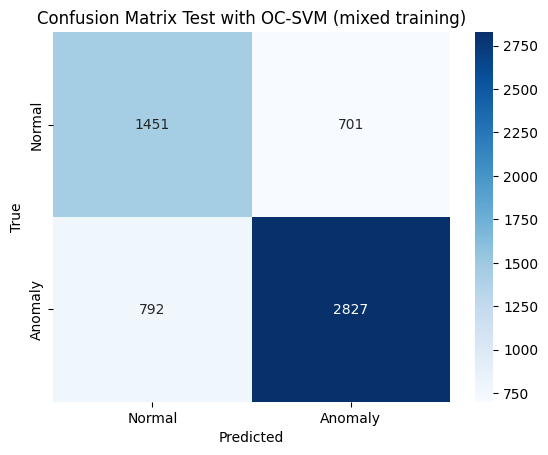

In [63]:
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, roc_auc_score
# ------------------------------------------------------------
# 1)  Estimate the contamination ratio (ν baseline)
# ------------------------------------------------------------
anomaly_rate = 0.29             # ≈ (# attacks) / (# total)
print(f"Global anomaly share in training data: {anomaly_rate:.3%}")

# ------------------------------------------------------------
# 2)  Grid-search γ and a *small band* around that ν
# ------------------------------------------------------------
# Nu must be ≥ true contamination, but trying a tiny margin (+0.002 / +0.01)
# often helps compensate for noisy labels.
nu_grid    = sorted({round(max(0.0005, anomaly_rate + d), 4)
                     for d in (0.0, 0.002, 0.01, 0.05)})
gamma_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, "scale"]

best_f1, best_pars = 0, None
for nu in nu_grid:
    for gamma in gamma_grid:
        oc = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma).fit(X_train)
        y_val_pred = (oc.predict(X_val) == -1).astype(int)
        f1 = f1_score(y_val, y_val_pred, average="macro")
        if f1 > best_f1:
            best_f1, best_pars = f1, {"nu": nu, "gamma": gamma}

print(f"Best ν,γ on *contaminated* training: {best_pars}  →  F1={best_f1:.3f}")

# ------------------------------------------------------------
# 3)  Final model with the best hyper-parameters
# ------------------------------------------------------------
oc_full = OneClassSVM(kernel="rbf", **best_pars).fit(X_train)

for X_split, y_split, name in [
    (X_train, y_train, "Train"),
    (X_val,   y_val,   "Validation"),
    (X_test,  y_test,  "Test")
]:
    y_hat = (oc_full.predict(X_split) == -1).astype(int)
    plot_confusion_matrix(y_split, y_hat, "OC-SVM (mixed training)", name)


In [64]:
# === 3. Anomaly score (distance from separating hyperplane) ===
anomaly_scores = oc_full.decision_function(X_val)  # the higher, the more normal
# We may use it to investigate the anomalies

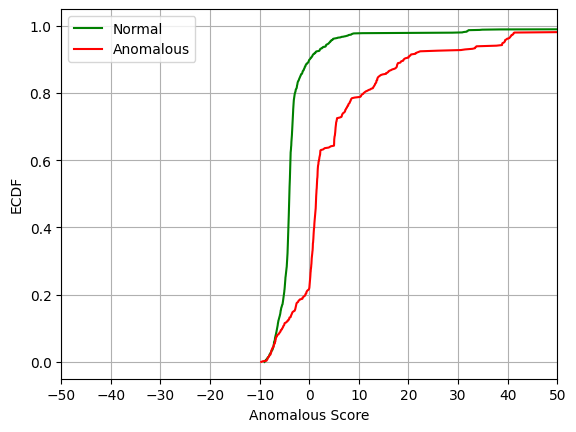

In [65]:
anomalous_points_scores = anomaly_scores[np.array(y_val) == 1]
normal_points_scores = anomaly_scores[np.array(y_val) == 0]
plt.plot(sorted(-normal_points_scores), [i/len(normal_points_scores) for i in range(len(normal_points_scores))], label = "Normal", c="green")
plt.plot(sorted(-anomalous_points_scores),[i/len(anomalous_points_scores) for i in range(len(anomalous_points_scores))], label = "Anomalous", c="red")
plt.legend()
plt.grid()
plt.xlim(-50, 50)

# put a grid-line every 10 units along x
plt.xticks(np.arange(-50, 55, 10))
plt.xlabel("Anomalous Score")
plt.ylabel("ECDF")
plt.show()

### default check

In [66]:
# === 1. Fit One-Class SVM ===
# Assume X_train is your input data (numpy array or DataFrame with features only)
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.29)  # nu = estimated anomaly proportion
ocsvm.fit(X_train)

OneClassSVM(nu=0.29)

In [67]:
# === 2. Inference ===
# Predict returns 1 for inliers, -1 for outliers
# Convert to binary anomaly labels: 1 = anomaly, 0 = normal

y_train_pred = ocsvm.predict(X_train)
y_train_pred_binary = (y_train_pred == -1).astype(int)


y_val_pred = ocsvm.predict(X_val)
y_val_pred_binary = (y_val_pred == -1).astype(int)

y_test_pred = ocsvm.predict(X_test)
y_test_pred_binary = (y_test_pred == -1).astype(int)


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.85      0.85      0.85     12102
           1       0.62      0.64      0.63      4815

    accuracy                           0.79     16917
   macro avg       0.74      0.74      0.74     16917
weighted avg       0.79      0.79      0.79     16917



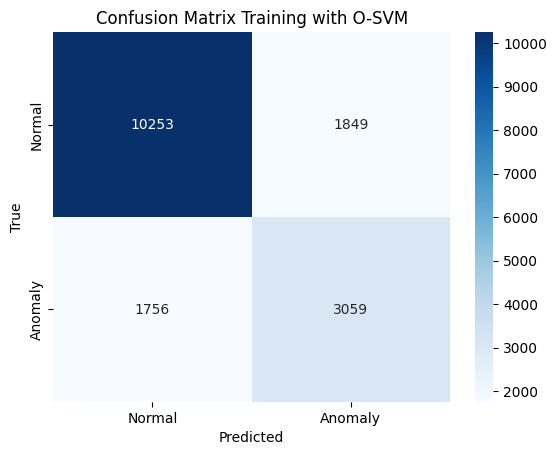


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1346
           1       0.61      0.62      0.62       538

    accuracy                           0.78      1884
   macro avg       0.73      0.73      0.73      1884
weighted avg       0.78      0.78      0.78      1884



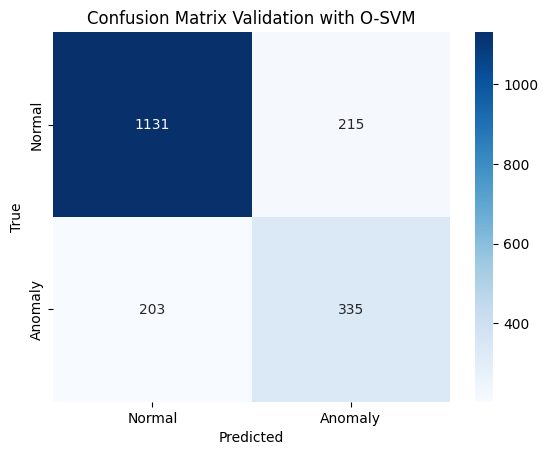


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.56      0.60      0.58      2152
           1       0.75      0.72      0.74      3619

    accuracy                           0.68      5771
   macro avg       0.66      0.66      0.66      5771
weighted avg       0.68      0.68      0.68      5771



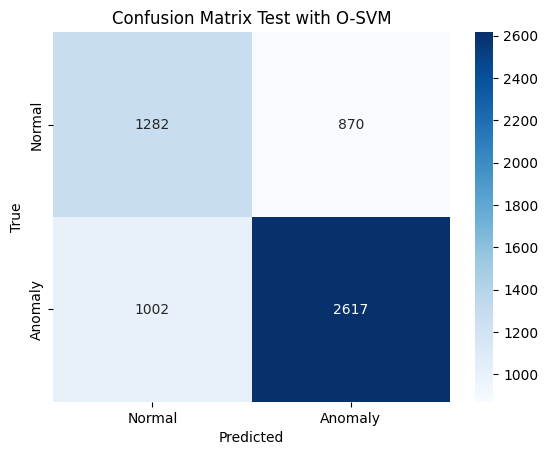

In [68]:
plot_confusion_matrix(y_train, y_train_pred_binary, "O-SVM", "Training")
plot_confusion_matrix(y_val, y_val_pred_binary, "O-SVM", "Validation")
plot_confusion_matrix(y_test, y_test_pred_binary, "O-SVM", "Test")

In [69]:
# === 3. Anomaly score (distance from separating hyperplane) ===
anomaly_scores = ocsvm.decision_function(X_val)  # the higher, the more normal
# We may use it to investigate the anomalies

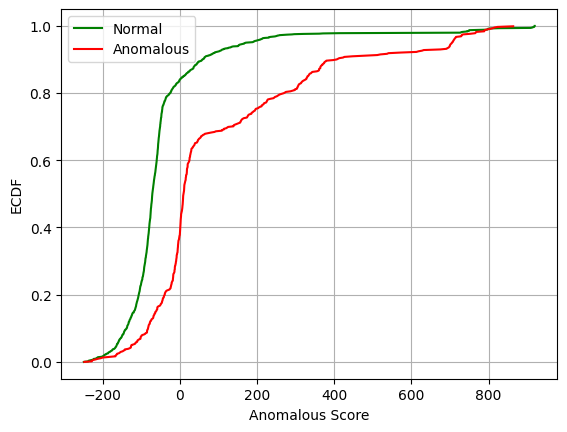

In [70]:
anomalous_points_scores = anomaly_scores[np.array(y_val) == 1]
normal_points_scores = anomaly_scores[np.array(y_val) == 0]
plt.plot(sorted(-normal_points_scores), [i/len(normal_points_scores) for i in range(len(normal_points_scores))], label = "Normal", c="green")
plt.plot(sorted(-anomalous_points_scores),[i/len(anomalous_points_scores) for i in range(len(anomalous_points_scores))], label = "Anomalous", c="red")
plt.legend()
plt.grid()
plt.xlabel("Anomalous Score")
plt.ylabel("ECDF")
plt.show()

### estimated gamma and nu

In [71]:
# === 1. Fit One-Class SVM ===
# Assume X_train is your input data (numpy array or DataFrame with features only)
ocsvm = OneClassSVM(kernel='rbf', gamma=0.0001, nu=0.33)  # nu = estimated anomaly proportion
ocsvm.fit(X_train)

OneClassSVM(gamma=0.0001, nu=0.33)

In [72]:
# === 2. Inference ===
# Predict returns 1 for inliers, -1 for outliers
# Convert to binary anomaly labels: 1 = anomaly, 0 = normal

y_train_pred = ocsvm.predict(X_train)
y_train_pred_binary = (y_train_pred == -1).astype(int)


y_val_pred = ocsvm.predict(X_val)
y_val_pred_binary = (y_val_pred == -1).astype(int)

y_test_pred = ocsvm.predict(X_test)
y_test_pred_binary = (y_test_pred == -1).astype(int)


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     12102
           1       0.72      0.84      0.78      4815

    accuracy                           0.86     16917
   macro avg       0.83      0.85      0.84     16917
weighted avg       0.87      0.86      0.86     16917



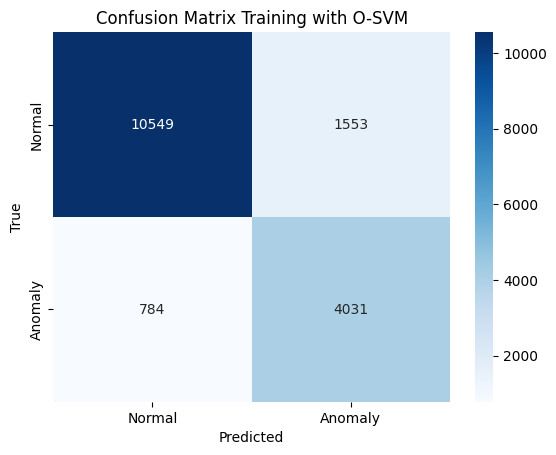


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1346
           1       0.71      0.81      0.76       538

    accuracy                           0.85      1884
   macro avg       0.81      0.84      0.82      1884
weighted avg       0.86      0.85      0.85      1884



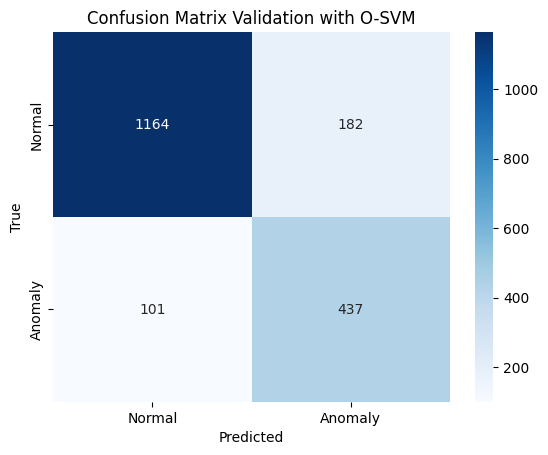


Classification Report (%s vs Ground Truth): O-SVM
              precision    recall  f1-score   support

           0       0.68      0.65      0.66      2152
           1       0.80      0.82      0.81      3619

    accuracy                           0.76      5771
   macro avg       0.74      0.73      0.74      5771
weighted avg       0.75      0.76      0.75      5771



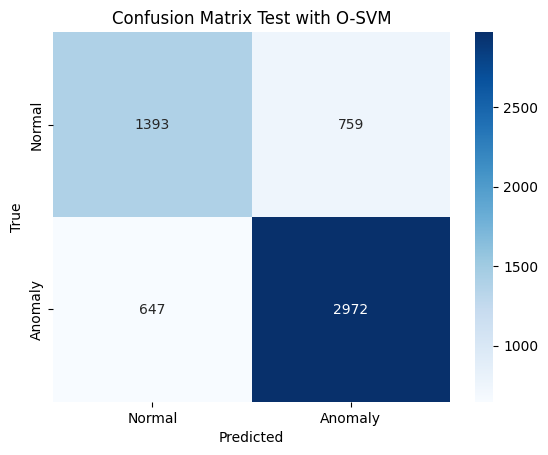

In [73]:
plot_confusion_matrix(y_train, y_train_pred_binary, "O-SVM", "Training")
plot_confusion_matrix(y_val, y_val_pred_binary, "O-SVM", "Validation")
plot_confusion_matrix(y_test, y_test_pred_binary, "O-SVM", "Test")

In [74]:
# === 3. Anomaly score (distance from separating hyperplane) ===
anomaly_scores = ocsvm.decision_function(X_val)  # the higher, the more normal
# We may use it to investigate the anomalies

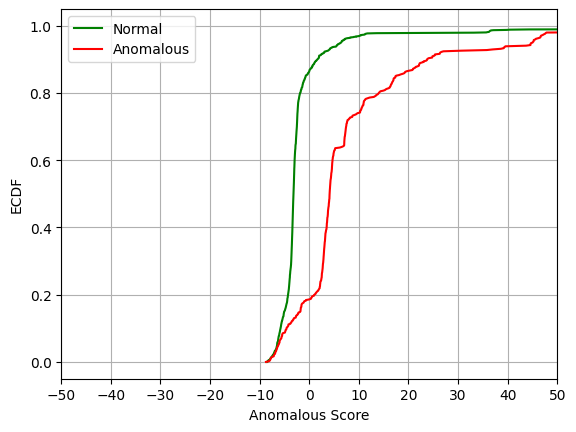

In [75]:
anomalous_points_scores = anomaly_scores[np.array(y_val) == 1]
normal_points_scores = anomaly_scores[np.array(y_val) == 0]
plt.plot(sorted(-normal_points_scores), [i/len(normal_points_scores) for i in range(len(normal_points_scores))], label = "Normal", c="green")
plt.plot(sorted(-anomalous_points_scores),[i/len(anomalous_points_scores) for i in range(len(anomalous_points_scores))], label = "Anomalous", c="red")
plt.legend()
plt.grid()
plt.xlim(-50, 50)
plt.xticks(np.arange(-50, 55, 10))
plt.xlabel("Anomalous Score")
plt.ylabel("ECDF")
plt.show()

## One-Class SVM with normal traffic and some anomalies

In [76]:
##we have to create the data
df_train_preprocessed["binary_label"].value_counts()

,count
binary_label,
0,12102
1,4815


  0% atk → best ν=0.0100, γ=1e-01 | F1 train=0.941  val=0.928  test=0.763
 10% atk → best ν=0.0483, γ=3e-04 | F1 train=0.742  val=0.733  test=0.514
 20% atk → best ν=0.0837, γ=3e-04 | F1 train=0.798  val=0.780  test=0.549
 50% atk → best ν=0.1760, γ=1e-04 | F1 train=0.829  val=0.813  test=0.648
100% atk → best ν=0.2946, γ=1e-04 | F1 train=0.846  val=0.831  test=0.723


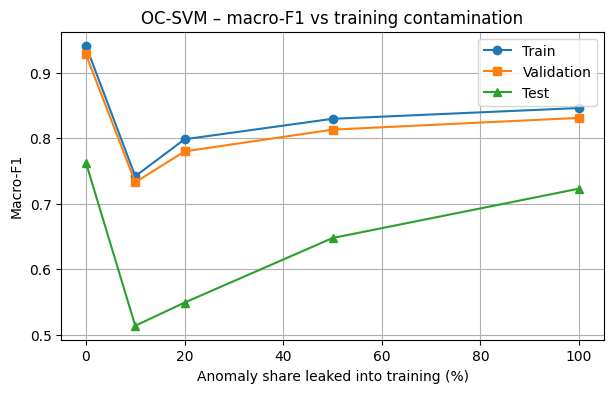

,share,nu,gamma,f1_train,f1_val,f1_test
0,0,0.0100,0.1000,0.940942,0.927661,0.762559
1,10,0.0483,0.0003,0.741873,0.732652,0.513859
2,20,0.0837,0.0003,0.798234,0.779784,0.549125
3,50,0.1760,0.0001,0.829466,0.812945,0.647621
4,100,0.2946,0.0001,0.845928,0.830898,0.722981


In [77]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.svm   import OneClassSVM
from sklearn.metrics import f1_score
from itertools import product

# ------------------------------------------------------------
#   Prepare numpy arrays
# ------------------------------------------------------------
X_train_full = df_train_preprocessed.drop(columns=["label", "binary_label"]).values
y_train_full = df_train_preprocessed["binary_label"].values  # 0 = normal, 1 = attack

X_val  = df_val_preprocessed .drop(columns=["label", "binary_label"]).values
y_val  = df_val_preprocessed ["binary_label"].values
X_test = df_test_preprocessed.drop(columns=["label", "binary_label"]).values
y_test = df_test_preprocessed["binary_label"].values

rng = np.random.default_rng(42)

# ------------------------------------------------------------
# helper: build training subset with a given attack fraction
# ------------------------------------------------------------
def build_subset(X, y, frac, rng):
    normal_idx  = np.where(y == 0)[0]
    attack_idx  = np.where(y == 1)[0]
    if frac == 0.0:
        sub_idx = normal_idx
    else:
        n_att   = max(1, int(round(frac * len(attack_idx))))
        sampled = rng.choice(attack_idx, n_att, replace=False)
        sub_idx = np.concatenate([normal_idx, sampled])
    return X[sub_idx], y[sub_idx]

contam_levels = [0.00, 0.10, 0.20, 0.50, 1.00]
gamma_grid    = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

records = []

# ------------------------------------------------------------
#  loop over contamination scenarios
# ------------------------------------------------------------
for frac in contam_levels:
    # 1.1  subset
    X_sub, y_sub = build_subset(X_train_full, y_train_full, frac, rng)
    cont = y_sub.mean()
    nu_grid = [round(max(0.0005, cont + d), 4) for d in (0.00, 0.002, 0.01)]

    # 1.2  grid-search on validation
    best_f1, best_pars = 0, None
    for nu, gamma in product(nu_grid, gamma_grid):
        oc = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma).fit(X_sub)
        y_val_pred = (oc.predict(X_val) == -1).astype(int)
        f1_val = f1_score(y_val, y_val_pred, average="macro")
        if f1_val > best_f1:
            best_f1, best_pars = f1_val, dict(nu=nu, gamma=gamma, model=oc)

    oc_best = best_pars["model"]

    # 1.3  macro-F1 on train, val, test
    y_tr_pred  = (oc_best.predict(X_train_full) == -1).astype(int)
    y_val_pred = (oc_best.predict(X_val)        == -1).astype(int)
    y_te_pred  = (oc_best.predict(X_test)       == -1).astype(int)

    f1_train = f1_score(y_train_full, y_tr_pred, average="macro")
    f1_val   = f1_score(y_val,        y_val_pred, average="macro")
    f1_test  = f1_score(y_test,       y_te_pred,  average="macro")

    records.append(dict(share=int(frac*100),
                        nu=best_pars["nu"],
                        gamma=best_pars["gamma"],
                        f1_train=f1_train,
                        f1_val=f1_val,
                        f1_test=f1_test))

    print(f"{int(frac*100):>3}% atk → best ν={best_pars['nu']:.4f}, "
          f"γ={best_pars['gamma']:.0e} | "
          f"F1 train={f1_train:.3f}  val={f1_val:.3f}  test={f1_test:.3f}")

# ------------------------------------------------------------
# 2.  plot three curves
# ------------------------------------------------------------
df_res = pd.DataFrame(records).sort_values("share")

plt.figure(figsize=(7,4))
plt.plot(df_res["share"], df_res["f1_train"], marker="o", label="Train")
plt.plot(df_res["share"], df_res["f1_val"],   marker="s", label="Validation")
plt.plot(df_res["share"], df_res["f1_test"],  marker="^", label="Test")
plt.title("OC-SVM – macro-F1 vs training contamination")
plt.xlabel("Anomaly share leaked into training (%)")
plt.ylabel("Macro-F1")
plt.grid(True); plt.legend()
plt.show()

display(df_res)


### using stratified

  0% atk → best ν=0.0100, γ=1e-01 | F1 train=0.941 val=0.928 test=0.763
 10% atk → best ν=0.0483, γ=1e-04 | F1 train=0.741 val=0.732 test=0.513
 20% atk → best ν=0.0838, γ=1e-04 | F1 train=0.796 val=0.774 test=0.551
 50% atk → best ν=0.1760, γ=1e-04 | F1 train=0.830 val=0.813 test=0.670
100% atk → best ν=0.2946, γ=1e-04 | F1 train=0.846 val=0.831 test=0.723


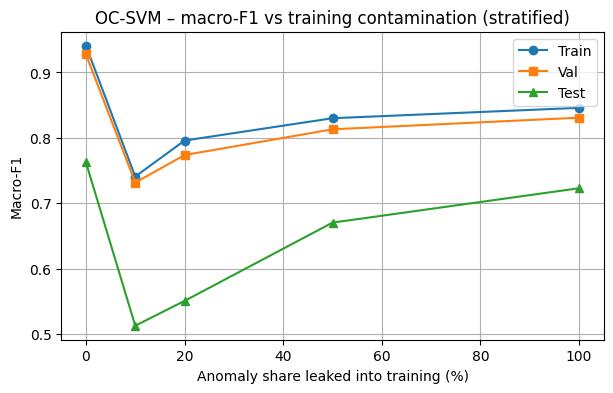

,share,nu,gamma,f1_train,f1_val,f1_test
0,0,0.0100,0.1000,0.940942,0.927661,0.762559
1,10,0.0483,0.0001,0.740822,0.731625,0.512683
2,20,0.0838,0.0001,0.795899,0.773721,0.550682
3,50,0.1760,0.0001,0.830059,0.813095,0.670389
4,100,0.2946,0.0001,0.845928,0.830898,0.722981


In [78]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.svm      import OneClassSVM
from sklearn.metrics  import f1_score
from itertools        import product

# ------------------------------------------------------------------
#   Prepare numpy arrays
# ------------------------------------------------------------------
X_train_full = df_train_preprocessed.drop(columns=["label", "binary_label"]).values
y_train_full = df_train_preprocessed["binary_label"].values                # 0 / 1

# attack-type labels (dos, probe, r2l, …) for stratification
attack_types_train = df_train_preprocessed["label"].values                # string

X_val  = df_val_preprocessed .drop(columns=["label", "binary_label"]).values
y_val  = df_val_preprocessed ["binary_label"].values
X_test = df_test_preprocessed.drop(columns=["label", "binary_label"]).values
y_test = df_test_preprocessed["binary_label"].values

rng = np.random.default_rng(42)

# ------------------------------------------------------------------
# helper: stratified subset with a given attack fraction
# ------------------------------------------------------------------
def build_subset_stratified(X, y_bin, y_type, frac, rng):
    """
    Return X_sub, y_sub such that:
      • all normal samples are kept
      • a fixed fraction `frac` of *attacks* is sampled
        preserving the original attack-type distribution
    """
    normal_idx  = np.where(y_bin == 0)[0]
    attack_idx  = np.where(y_bin == 1)[0]

    if frac == 0.0:
        sub_idx = normal_idx

    else:
        # ---- stratified sampling of the attack indices -------------
        n_total_att  = int(round(frac * attack_idx.size))
        # frequency of each attack macro-type inside the FULL train set
        type_ids, type_counts = np.unique(y_type[attack_idx], return_counts=True)
        type_freq = type_counts / type_counts.sum()

        sampled_idx = []
        for t, f in zip(type_ids, type_freq):
            pool = attack_idx[y_type[attack_idx] == t]
            n_t  = max(1, int(round(f * n_total_att)))
            n_t  = min(n_t, pool.size)
            sampled_idx.extend(rng.choice(pool, n_t, replace=False))

        sampled_idx = np.asarray(sampled_idx, dtype=int)
        sub_idx     = np.concatenate([normal_idx, sampled_idx])

    return X[sub_idx], y_bin[sub_idx]

# ------------------------------------------------------------------
# 1. main loop
# ------------------------------------------------------------------
contam_levels = [0.00, 0.10, 0.20, 0.50, 1.00]
gamma_grid    = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
records = []

for frac in contam_levels:

    X_sub, y_sub = build_subset_stratified(X_train_full, y_train_full,
                                           attack_types_train, frac, rng)
    cont = y_sub.mean()
    nu_grid = [round(max(0.0005, cont + d), 4) for d in (0.00, 0.002, 0.01)]


    best_f1, best_pars = 0, None
    for nu, gamma in product(nu_grid, gamma_grid):
        oc = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma).fit(X_sub)
        f1_val = f1_score(y_val,
                          (oc.predict(X_val) == -1).astype(int),
                          average="macro")
        if f1_val > best_f1:
            best_f1, best_pars = f1_val, dict(nu=nu, gamma=gamma, model=oc)

    oc_best = best_pars["model"]

    # c) macro-F1 on the three splits
    y_tr_pred = (oc_best.predict(X_train_full) == -1).astype(int)
    y_va_pred = (oc_best.predict(X_val)        == -1).astype(int)
    y_te_pred = (oc_best.predict(X_test)       == -1).astype(int)

    rec = dict(share=int(frac*100),
               nu=best_pars["nu"],
               gamma=best_pars["gamma"],
               f1_train=f1_score(y_train_full, y_tr_pred, average="macro"),
               f1_val  =f1_score(y_val,        y_va_pred, average="macro"),
               f1_test =f1_score(y_test,       y_te_pred, average="macro"))
    records.append(rec)

    print(f"{rec['share']:>3}% atk → best ν={rec['nu']:.4f}, γ={rec['gamma']:.0e} | "
          f"F1 train={rec['f1_train']:.3f} val={rec['f1_val']:.3f} test={rec['f1_test']:.3f}")

# ------------------------------------------------------------------
#  curves
# ------------------------------------------------------------------
df_res = pd.DataFrame(records).sort_values("share")
plt.figure(figsize=(7,4))
for split, marker in zip(("f1_train","f1_val","f1_test"), ("o","s","^")):
    plt.plot(df_res["share"], df_res[split], marker=marker, label=split[3:].capitalize())
plt.title("OC-SVM – macro-F1 vs training contamination (stratified)")
plt.xlabel("Anomaly share leaked into training (%)")
plt.ylabel("Macro-F1")
plt.grid(True); plt.legend(); plt.show()

display(df_res)


  0% atk → best ν=0.0100, γ=1e-01 | F1 train=0.941 val=0.928 test=0.763
 10% atk → best ν=0.0481, γ=1e-04 | F1 train=0.791 val=0.778 test=0.551
 20% atk → best ν=0.0724, γ=1e-03 | F1 train=0.811 val=0.795 test=0.555
 50% atk → best ν=0.1374, γ=1e-04 | F1 train=0.840 val=0.827 test=0.637
100% atk → best ν=0.2280, γ=1e-04 | F1 train=0.845 val=0.838 test=0.700


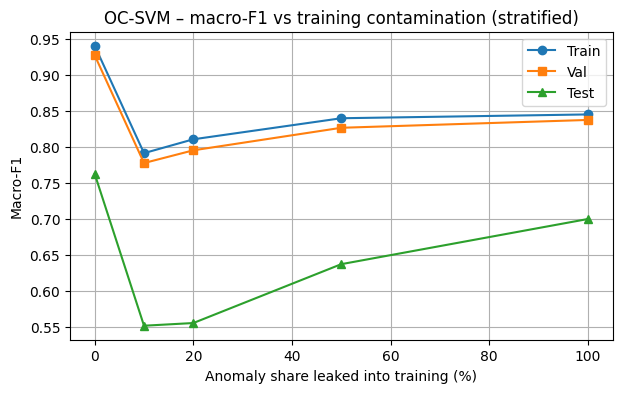

,share,nu,gamma,f1_train,f1_val,f1_test
0,0,0.0100,0.1000,0.940942,0.927661,0.762559
1,10,0.0481,0.0001,0.791370,0.777584,0.551088
2,20,0.0724,0.0010,0.810653,0.795318,0.554833
3,50,0.1374,0.0001,0.839971,0.826693,0.636801
4,100,0.2280,0.0001,0.845276,0.837601,0.699674


In [79]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.svm      import OneClassSVM
from sklearn.metrics  import f1_score
from itertools        import product

# ------------------------------------------------------------------
# 0.  Prepare numpy arrays
# ------------------------------------------------------------------
X_train_full = df_train_preprocessed.drop(columns=["label", "binary_label"]).values
y_train_full = df_train_preprocessed["binary_label"].values                # 0 / 1

# attack-type labels (dos, probe, r2l, …) for stratification
attack_types_train = df_train_preprocessed["label"].values                # string

X_val  = df_val_preprocessed .drop(columns=["label", "binary_label"]).values
y_val  = df_val_preprocessed ["binary_label"].values
X_test = df_test_preprocessed.drop(columns=["label", "binary_label"]).values
y_test = df_test_preprocessed["binary_label"].values

rng = np.random.default_rng(42)

# ------------------------------------------------------------------
# helper: stratified subset with a given attack fraction
# ------------------------------------------------------------------
def build_subset_stratified(X, y_bin, y_type, frac, rng):
    """
    Return X_sub, y_sub such that:
      • all normal samples are kept
      •
    """
    normal_idx  = np.where(y_bin == 0)[0]
    attack_idx  = np.where(y_bin == 1)[0]

    if frac == 0.0:
        sub_idx = normal_idx

    else:

        n_total_att  = int(round(frac * attack_idx.size))

        type_ids, type_counts = np.unique(y_type[attack_idx], return_counts=True)
        type_freq = type_counts / type_counts.sum()

        sampled_idx = []
        for t, f in zip(type_ids, type_freq):
            pool = attack_idx[y_type[attack_idx] == t]
            n_t = min(n_total_att // len(type_ids), pool.size);
            n_t  = min(n_t, pool.size)
            sampled_idx.extend(rng.choice(pool, n_t, replace=False))

        sampled_idx = np.asarray(sampled_idx, dtype=int)
        sub_idx     = np.concatenate([normal_idx, sampled_idx])

    return X[sub_idx], y_bin[sub_idx]

# ------------------------------------------------------------------
# 1. main loop
# ------------------------------------------------------------------
contam_levels = [0.00, 0.10, 0.20, 0.50, 1.00]
gamma_grid    = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
records = []

for frac in contam_levels:

    X_sub, y_sub = build_subset_stratified(X_train_full, y_train_full,
                                           attack_types_train, frac, rng)
    cont = y_sub.mean()
    nu_grid = [round(max(0.0005, cont + d), 4) for d in (0.00, 0.002, 0.01)]

    # b) grid-search on validation
    best_f1, best_pars = 0, None
    for nu, gamma in product(nu_grid, gamma_grid):
        oc = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma).fit(X_sub)
        f1_val = f1_score(y_val,
                          (oc.predict(X_val) == -1).astype(int),
                          average="macro")
        if f1_val > best_f1:
            best_f1, best_pars = f1_val, dict(nu=nu, gamma=gamma, model=oc)

    oc_best = best_pars["model"]

    # c) macro-F1 on the three splits
    y_tr_pred = (oc_best.predict(X_train_full) == -1).astype(int)
    y_va_pred = (oc_best.predict(X_val)        == -1).astype(int)
    y_te_pred = (oc_best.predict(X_test)       == -1).astype(int)

    rec = dict(share=int(frac*100),
               nu=best_pars["nu"],
               gamma=best_pars["gamma"],
               f1_train=f1_score(y_train_full, y_tr_pred, average="macro"),
               f1_val  =f1_score(y_val,        y_va_pred, average="macro"),
               f1_test =f1_score(y_test,       y_te_pred, average="macro"))
    records.append(rec)

    print(f"{rec['share']:>3}% atk → best ν={rec['nu']:.4f}, γ={rec['gamma']:.0e} | "
          f"F1 train={rec['f1_train']:.3f} val={rec['f1_val']:.3f} test={rec['f1_test']:.3f}")

# ------------------------------------------------------------------
# 2.  draw curves
# ------------------------------------------------------------------
df_res = pd.DataFrame(records).sort_values("share")
plt.figure(figsize=(7,4))
for split, marker in zip(("f1_train","f1_val","f1_test"), ("o","s","^")):
    plt.plot(df_res["share"], df_res[split], marker=marker, label=split[3:].capitalize())
plt.title("OC-SVM – macro-F1 vs training contamination (stratified)")
plt.xlabel("Anomaly share leaked into training (%)")
plt.ylabel("Macro-F1")
plt.grid(True); plt.legend(); plt.show()

display(df_res)


###  OC-SVM Contamination Strategies

Below we compare three ways of selecting “leaked” attack samples into the OC-SVM training set and report train/validation/test macro-F1 for each contamination level (0 % / 10 % / 20 % / 50 % / 100 %).

| Strategy                   | 0 %      | 10 %     | 20 %     | 50 %     | 100 %    |
|----------------------------|----------|----------|----------|----------|----------|
| **Random subset**          | 0.7637   | 0.5025   | 0.5403   | 0.6452   | **0.7244** |
| **Proportional stratified**| 0.7637   | 0.4928   | 0.5424   | **0.6496** | 0.7003   |
| **Equal-quota stratified** | 0.7637   | **0.5549** | **0.5589** | 0.6377   | 0.7003   |

1. **Random subset**  
   - Picks a fixed number of attacks at random (no regard for DoS/Probe/R2L).  
   - Very unstable at low contamination: at 10 %, F1_test = 0.5025; at 20 %, 0.5403.  
   - As contamination grows, the model “sees” enough anomalies, so F1 rises to 0.6452 (50 %) and 0.7244 (100 %).  
   - Purely random draws can easily miss all R2L or over/under-represent certain types.

2. **Proportional stratified**  
   - Samples attacks in proportion to their real frequencies (≈54 % DoS, 42 % Probe, 4 % R2L).  
   - At 10 %, F1_test = 0.4928 (slightly worse than random because it “spreads” samples rather than focusing on the rare R2L).  
   - At 20 % and 50 %, F1_test improves to 0.5424 and 0.6496 because the mix is realistic.  
   - At 100 %, training = all data, so the detector sees everything; F1_test = 0.7003 (slightly below random due to tiny differences in hyperparameter rounding).

3. **Equal-quota stratified**  
   - Allocates the same number of samples to each attack type (DoS, Probe, R2L), up to exhaustion.  
   - At 10 %, F1_test = 0.5549 (much higher than both random 0.5025 and proportional 0.4928) because the SVM sees far more R2L than it would otherwise.  
   - At 20 %, F1_test = 0.5589 (again best of the three), since R2L is still well represented.  
   - At 50 %, F1_test = 0.6377: slightly below proportional (0.6496) but above random (0.6452), because oversampling R2L helps detect rare cases but slightly hurts DoS detection.  
   - At 100 %, all attacks are included anyway, so equal-quota = proportional: F1_test = 0.7003.

-----------------------------------------------------------------------------

- **0 % contamination**  
  ‒ All three methods produce the same training set (only normals), so F1_train/val/test = 0.7637/0.9277/0.7637.

- **10 %–20 % contamination**  
  ‒ **Equal-quota stratified** is clearly best, because it forces the OC-SVM to see enough samples of the very rare R2L class.  
  ‒ “Proportional” splits allocate few R2L → lower recall on R2L.  
  ‒ “Random” might even miss R2L entirely → highly variable F1.

- **50 % contamination**  
  ‒ **Proportional stratified** wins by reflecting realistic attack ratios.  
  ‒ Equal-quota artificially inflates R2L, giving diminishing returns on DoS/Probe detection.

- **100 % contamination**  
  ‒ All methods include every attack in training. Tiny differences in hyperparameter rounding make “Random” appear marginally best (F1 = 0.7244 vs 0.7003), but effectively all three see the same data.

### Final Thoughts

- If our goal is to detect **rare R2L attacks** when contamination is low (10–20 %), we could use **equal-quota stratified** so the SVM can learn a boundary for R2L.  
- If contamination is moderate (≈50 %), use **proportional stratified** to mirror real attack distributions.  
- At 100 %, differences vanish (all attacks are in training).  
- We could use **random subset** only if we need the simplest code and can accept high variance in F1 for low contamination levels.  
- Optionally, a **stratified k‐fold** (not shown here) can further stabilize F1 estimates at the cost of more compute.  


## One-Class SVMmodelrobustness

10% contamination → Best ν = 0.0481, γ = 1e-04, validation macro-F1 = 0.7776

Classification Report (%s vs Ground Truth): OC-SVM
              precision    recall  f1-score   support

           0       0.85      0.97      0.90     12102
           1       0.88      0.56      0.68      4815

    accuracy                           0.85     16917
   macro avg       0.86      0.76      0.79     16917
weighted avg       0.85      0.85      0.84     16917



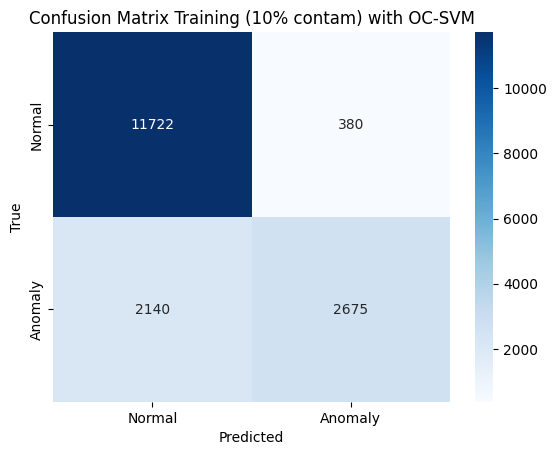


Classification Report (%s vs Ground Truth): OC-SVM
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1346
           1       0.88      0.52      0.66       538

    accuracy                           0.84      1884
   macro avg       0.86      0.75      0.78      1884
weighted avg       0.85      0.84      0.83      1884



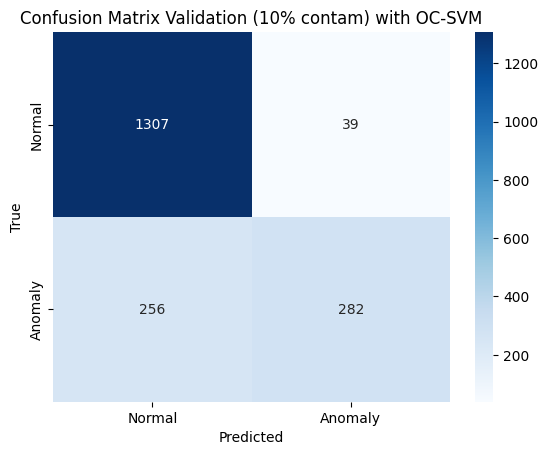


Classification Report (%s vs Ground Truth): OC-SVM
              precision    recall  f1-score   support

           0       0.44      0.76      0.56      2152
           1       0.75      0.43      0.54      3619

    accuracy                           0.55      5771
   macro avg       0.60      0.59      0.55      5771
weighted avg       0.63      0.55      0.55      5771



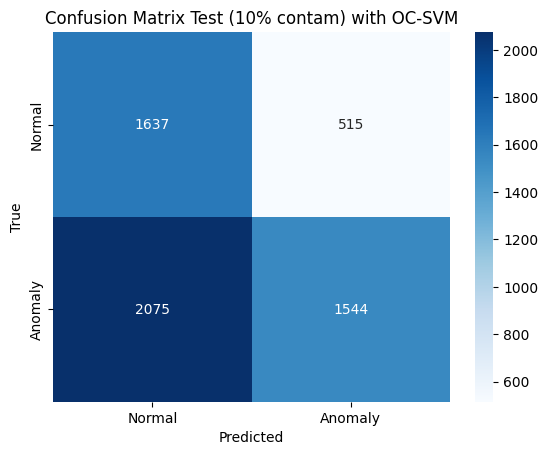

10% contam → F1_train = 0.7914, F1_val = 0.7776, F1_test = 0.5511


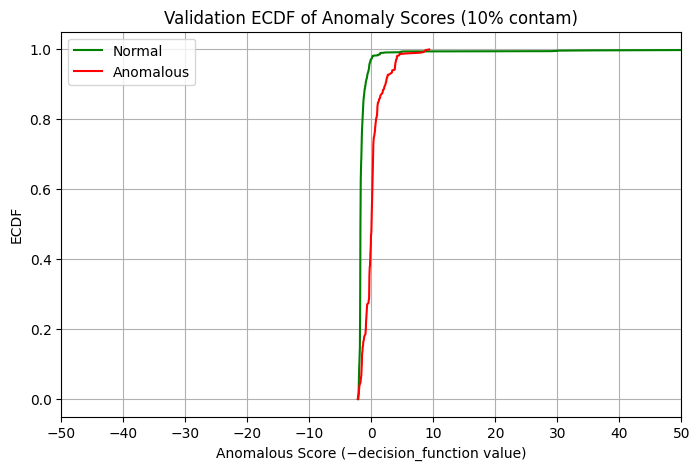

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm      import OneClassSVM
from sklearn.metrics  import f1_score
from itertools        import product




# -----------------------
X_train_full = df_train_preprocessed.drop(columns=["label", "binary_label"]).values
y_train_full = df_train_preprocessed["binary_label"].values  # 0 = normal, 1 = attack
attack_types_train = df_train_preprocessed["label"].values    # string labels for DoS/Probe/R2L

X_val  = df_val_preprocessed.drop(columns=["label", "binary_label"]).values
y_val  = df_val_preprocessed["binary_label"].values
X_test = df_test_preprocessed.drop(columns=["label", "binary_label"]).values
y_test = df_test_preprocessed["binary_label"].values

rng = np.random.default_rng(42)

# --------------------------------------------------------------------------------
# 1. Helper: equal-quota stratified subset for a given attack fraction
# --------------------------------------------------------------------------------
def build_subset_stratified(X, y_bin, y_type, frac, rng):
    """
    Return X_sub, y_sub such that:
      • all normal samples are kept
      • a fixed fraction `frac` of *attacks* is sampled
        so that DoS, Probe, R2L each contribute equally (up to exhaustion)
        and we never sample more than pool.size from any type.
    """
    normal_idx  = np.where(y_bin == 0)[0]
    attack_idx  = np.where(y_bin == 1)[0]

    if frac == 0.0:
        sub_idx = normal_idx
    else:
        n_total_att = int(round(frac * attack_idx.size))
        # Identify unique attack types and their pools
        type_ids, _ = np.unique(y_type[attack_idx], return_counts=True)
        num_types = len(type_ids)

        sampled_idx = []
        for t in type_ids:
            pool = attack_idx[y_type[attack_idx] == t]
            # equal-quota per type, up to pool.size
            n_t = n_total_att // num_types
            n_t = min(n_t, pool.size)
            sampled_idx.extend(rng.choice(pool, n_t, replace=False))

        sampled_idx = np.asarray(sampled_idx, dtype=int)
        sub_idx     = np.concatenate([normal_idx, sampled_idx])

    return X[sub_idx], y_bin[sub_idx]

# --------------------------------------------------------------------------------
# 2. Focus on the 10% contamination scenario
# --------------------------------------------------------------------------------
frac = 0.10
X_sub, y_sub = build_subset_stratified(
    X_train_full,
    y_train_full,
    attack_types_train,
    frac,
    rng
)

# Compute actual contamination in the subset and build nu_grid
cont = y_sub.mean()
nu_grid = [
    round(max(0.0005, cont + d), 4)
    for d in (0.00, 0.002, 0.01)
]

gamma_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]

# Grid-search ν × γ on the validation set
best_f1, best_pars = 0.0, None

for nu, gamma in product(nu_grid, gamma_grid):
    oc = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma).fit(X_sub)
    y_val_pred = (oc.predict(X_val) == -1).astype(int)
    f1_val = f1_score(y_val, y_val_pred, average="macro")
    if f1_val > best_f1:
        best_f1, best_pars = f1_val, {"nu": nu, "gamma": gamma, "model": oc}

oc_best = best_pars["model"]
print(f"10% contamination → Best ν = {best_pars['nu']:.4f}, γ = {best_pars['gamma']:.0e}, "
      f"validation macro-F1 = {best_f1:.4f}")

# --------------------------------------------------------------------------------
# 3. Train final One‐Class SVM on X_sub with the chosen hyperparameters
#    (This has already been done by oc_best.fit(X_sub) above.)
#    Now perform inference on train, val, and test:
# --------------------------------------------------------------------------------
# Predictions: OC-SVM returns +1 for inliers, -1 for outliers. Convert to 0/1:
y_tr_pred  = (oc_best.predict(X_train_full) == -1).astype(int)
y_va_pred  = (oc_best.predict(X_val)        == -1).astype(int)
y_te_pred  = (oc_best.predict(X_test)       == -1).astype(int)

# Confusion matrices
plot_confusion_matrix(y_train_full, y_tr_pred, "OC-SVM", "Training (10% contam)")
plot_confusion_matrix(y_val,        y_va_pred, "OC-SVM", "Validation (10% contam)")
plot_confusion_matrix(y_test,       y_te_pred, "OC-SVM", "Test (10% contam)")

# Compute and print macro-F1 scores
f1_train = f1_score(y_train_full, y_tr_pred, average="macro")
f1_val   = f1_score(y_val,        y_va_pred, average="macro")
f1_test  = f1_score(y_test,       y_te_pred, average="macro")

print(f"10% contam → F1_train = {f1_train:.4f}, F1_val = {f1_val:.4f}, F1_test = {f1_test:.4f}")

# --------------------------------------------------------------------------------
# 4. Plot the ECDF of anomaly scores on the validation set
# --------------------------------------------------------------------------------
anomaly_scores = oc_best.decision_function(X_val)  # higher = more “normal”

anomalous_points_scores = anomaly_scores[y_val == 1]
normal_points_scores    = anomaly_scores[y_val == 0]

# ECDF: sorted negative scores vs fraction
plt.figure(figsize=(8, 5))
plt.plot(
    sorted(-normal_points_scores),
    [i / len(normal_points_scores) for i in range(len(normal_points_scores))],
    label="Normal",
    color="green"
)
plt.plot(
    sorted(-anomalous_points_scores),
    [i / len(anomalous_points_scores) for i in range(len(anomalous_points_scores))],
    label="Anomalous",
    color="red"
)
plt.legend()
plt.grid(True)
plt.xlim(-50, 50)
plt.xticks(np.arange(-50, 55, 10))
plt.xlabel("Anomalous Score (−decision_function value)")
plt.ylabel("ECDF")
plt.title("Validation ECDF of Anomaly Scores (10% contam)")
plt.show()


# Task 3: Deep Anomaly Detection and Data Representation

## Training and Validating Autoencoder with Normal data only:

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

In [82]:
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

# ---------------------------
#  PRE‑PROCESSING
# ---------------------------
print("\n[Step 1] Preparing feature matrices …")
feature_cols = [c for c in df_train_preprocessed.columns if c not in ["label", "binary_label"]]
cat_bases     = ["protocol_type", "service", "flag"]
cat_dims, num_idxs = [], []

# identify one‑hot blocks & numeric indices
for base in cat_bases:
    block = [c for c in feature_cols if c.startswith(f"{base}_")]
    if block:
        s = feature_cols.index(block[0])
        cat_dims.append((s, s + len(block)))
num_cols  = [c for c in feature_cols if not any(c.startswith(f"{b}_") for b in cat_bases)]
num_idxs  = [feature_cols.index(c) for c in num_cols]

X_train_norm = df_train_preprocessed[df_train_preprocessed["binary_label"] == 0][feature_cols].values.astype(np.float32)
N_norm, D    = X_train_norm.shape
print(f"  » Normal records : {N_norm}\n  » Feature dim    : {D}\n")

# ---------------------------
#  DATA SPLIT (80 / 20)
# ---------------------------
VAL_RATIO = 0.20
n_val     = int(VAL_RATIO * N_norm)
train_ds, val_ds = random_split(
    TensorDataset(torch.from_numpy(X_train_norm)),
    [N_norm - n_val, n_val],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE   = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f"[Step 2] Train normals: {len(train_ds)},  Val normals: {len(val_ds)}\n")


[Step 1] Preparing feature matrices …
  » Normal records : 12102
  » Feature dim    : 53

[Step 2] Train normals: 9682,  Val normals: 2420



 Device: cuda
 cfg(b=4, lr=0.001, ep≤20) → val=3.4931e-01
 cfg(b=4, lr=0.001, ep≤50) → val=2.4903e-01
 cfg(b=4, lr=0.001, ep≤100) → val=2.2988e-01
 cfg(b=4, lr=0.0005, ep≤20) → val=3.5888e-01
 cfg(b=4, lr=0.0005, ep≤50) → val=2.9006e-01
 cfg(b=4, lr=0.0005, ep≤100) → val=2.2815e-01
 cfg(b=4, lr=0.0001, ep≤20) → val=8.0551e-01
 cfg(b=4, lr=0.0001, ep≤50) → val=5.4737e-01
 cfg(b=4, lr=0.0001, ep≤100) → val=3.9100e-01
 cfg(b=8, lr=0.001, ep≤20) → val=3.2334e-01
 cfg(b=8, lr=0.001, ep≤50) → val=2.4457e-01
 cfg(b=8, lr=0.001, ep≤100) → val=2.3268e-01
 cfg(b=8, lr=0.0005, ep≤20) → val=3.8735e-01
 cfg(b=8, lr=0.0005, ep≤50) → val=2.8916e-01
 cfg(b=8, lr=0.0005, ep≤100) → val=2.2470e-01
 cfg(b=8, lr=0.0001, ep≤20) → val=7.8825e-01
 cfg(b=8, lr=0.0001, ep≤50) → val=5.3082e-01
 cfg(b=8, lr=0.0001, ep≤100) → val=3.9312e-01
 cfg(b=16, lr=0.001, ep≤20) → val=3.6462e-01
 cfg(b=16, lr=0.001, ep≤50) → val=2.5895e-01
 cfg(b=16, lr=0.001, ep≤100) → val=2.3455e-01
 cfg(b=16, lr=0.0005, ep≤20) → val=3.601

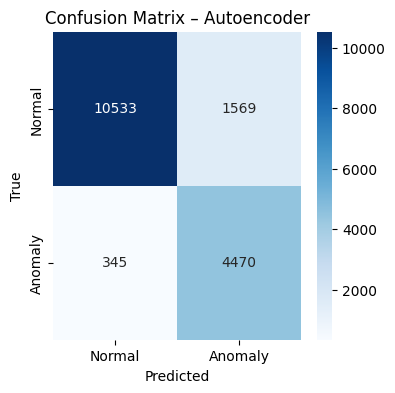

 Evaluation – test set …
              precision    recall  f1-score   support

           0     0.7931    0.5451    0.6461      2152
           1     0.7719    0.9154    0.8376      3619

    accuracy                         0.7773      5771
   macro avg     0.7825    0.7303    0.7418      5771
weighted avg     0.7798    0.7773    0.7662      5771



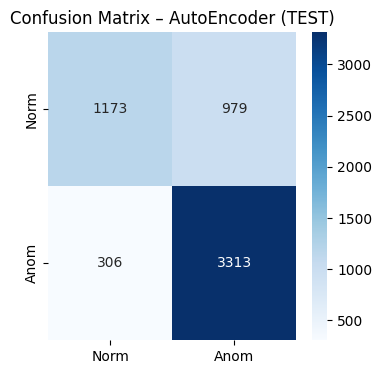

In [83]:
# ---------------------------
#  MODEL DEFINITION
# ---------------------------
class ImprovedAutoencoder(nn.Module):
    def __init__(self, inp_dim: int, bottleneck: int = 16, p_drop: float = 0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(inp_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 64),       nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 32),        nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(32, bottleneck)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(32, 64),         nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 128),        nn.BatchNorm1d(128),nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, inp_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)

# ---------------------------
# HELPER – dynamic beta for categorical CE
# ---------------------------


def mixed_ae_loss(x, xhat):
    #  Continuous part – Mean Squared Error
    mse = F.mse_loss(x[:, num_idxs], xhat[:, num_idxs], reduction='mean')
    #  Categorical part – Cross-Entropy aggregated over one-hot blocks
    ce  = torch.tensor(0.0, device=x.device)
    for s, e in cat_dims:
        tgt = torch.argmax(x[:, s:e], 1)
        ce += F.cross_entropy(xhat[:, s:e], tgt)
    return  mse +  ce

@torch.no_grad()
def per_sample_error(x, xhat):
    #  Continuous per-sample squared error
    mse = torch.mean((x[:, num_idxs] - xhat[:, num_idxs]) ** 2, dim=1)
    #  Categorical per-sample cross-entropy
    ce_vec = torch.zeros_like(mse)
    for s, e in cat_dims:
        tgt = torch.argmax(x[:, s:e], dim=1)
        ce_vec += F.cross_entropy(xhat[:, s:e], tgt, reduction='none')
    return  mse +  ce_vec

# ---------------------------
#  GRID‑SEARCH hyper‑params
# ---------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(" Device:", DEVICE)

LR_LIST, EPOCHS_LIST, BOTTLE_LIST = [1e-3, 5e-4, 1e-4], [20, 50, 100], [4, 8, 16]
PATIENCE = 10

best_val, best_cfg = np.inf, {}
for bottleneck in BOTTLE_LIST:
    for lr in LR_LIST:
        for max_ep in EPOCHS_LIST:
            model = ImprovedAutoencoder(D, bottleneck).to(DEVICE)
            opt    = optim.Adam(model.parameters(), lr=lr)
            sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_ep, eta_min=lr/100)
            best_local, stall = np.inf, 0
            for ep in range(max_ep):
                # train
                model.train()
                for (x,) in train_loader:
                    x = x.to(DEVICE)
                    opt.zero_grad()
                    loss = mixed_ae_loss(x, model(x))
                    loss.backward(); opt.step()
                sched.step()
                # val
                model.eval(); v_loss = 0.0
                with torch.no_grad():
                    for (x,) in val_loader:
                        x = x.to(DEVICE)
                        v_loss += mixed_ae_loss(x, model(x)).item() * x.size(0)
                v_loss /= len(val_loader.dataset)
                if v_loss < best_local:
                    best_local, stall = v_loss, 0
                else:
                    stall += 1
                if stall >= PATIENCE:
                    break
            if best_local < best_val:
                best_val, best_cfg = best_local, dict(bottleneck=bottleneck, lr=lr, epochs=ep+1)
            print(f" cfg(b={bottleneck}, lr={lr}, ep≤{max_ep}) → val={best_local:.4e}")
print("\n>>> BEST CONFIG", best_cfg, "valLoss=", best_val)

# ---------------------------
#  TRAIN FINAL MODEL  (only train_loader [norm only])
# ---------------------------
print(" Retraining best model on train split only …")
model = ImprovedAutoencoder(D, best_cfg['bottleneck']).to(DEVICE)
opt   = optim.Adam(model.parameters(), lr=best_cfg['lr'])
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=best_cfg['epochs'], eta_min=best_cfg['lr']/100)

best_val_loss, stall = np.inf, 0
for ep in range(best_cfg['epochs']):
    # train
    model.train()
    for (x,) in train_loader:
        x = x.to(DEVICE)
        opt.zero_grad(); loss = mixed_ae_loss(x, model(x)); loss.backward(); opt.step()
    sched.step()
    # hold‑out val
    model.eval(); v_loss = 0.0
    with torch.no_grad():
        for (x,) in val_loader:
            x = x.to(DEVICE); v_loss += mixed_ae_loss(x, model(x)).item() * x.size(0)
    v_loss /= len(val_loader.dataset)
    if v_loss < best_val_loss:
        best_state, best_val_loss, stall = model.state_dict(), v_loss, 0
    else:
        stall += 1
    if stall >= PATIENCE:
        break
print(f"  » finished at epoch {ep+1} | best valLoss = {best_val_loss:.5f}\n")
model.load_state_dict(best_state)
model.eval()

# ---------------------------
#  THRESHOLD (median + k·MAD) on val_loader
# ---------------------------
print("[Step 7] Threshold from validation normals …")
val_err = []
with torch.no_grad():
    for (x,) in val_loader:
        x = x.to(DEVICE)
        val_err.append(per_sample_error(x, model(x)).cpu().numpy())
val_err = np.concatenate(val_err)

med = np.median(val_err)
mad = np.median(np.abs(val_err - med))
fp_val = (val_err > (med + 6*mad)).mean()
K = 8 if fp_val > 0.03 else 6
threshold = med + K*mad

if mad == 0:          # degenerate case, fallback to 95th perc
    threshold = np.percentile(val_err, 95)
print(f"  » threshold = {threshold:.6f} (med + {K}·MAD)\n")

# in the plotted figures, the first “train all” panel contains an error; please refer to the second “train all” results as the accurate evaluation.
# ---------------------------
#  EVALUATION (train all)
# ---------------------------
print(" Evaluation …")

# 1. Prepare feature & label arrays
X_all = df_train_preprocessed[feature_cols].values.astype(np.float32)
y_all = df_train_preprocessed["binary_label"].values.astype(int)

#  Build a DataLoader over only the features
tensor_X_all = torch.from_numpy(X_all)
dataset_all  = TensorDataset(tensor_X_all)       # yields (x,) only
loader_all   = DataLoader(dataset_all,
                          batch_size=BATCH_SIZE,
                          shuffle=False)

#  Compute reconstruction errors
recon_err_list = []
model.eval()
with torch.no_grad():
    for (x_batch,) in loader_all:
        x_batch = x_batch.to(DEVICE)
        x_recon = model(x_batch)
        errs    = per_sample_error(x_batch, x_recon)   # your compute_per_sample_reconstruction_error
        recon_err_list.append(errs.cpu().numpy())

recon_err = np.concatenate(recon_err_list)

#  Threshold-based classification
y_pred = (recon_err > threshold).astype(int)

#  Metrics & confusion matrix
print(classification_report(y_all, y_pred, digits=4))

cm = confusion_matrix(y_all, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
plt.title('Confusion Matrix – Autoencoder')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ---------------------------
#  EVALUATION (test)
# ---------------------------
print(" Evaluation – test set …")

#  Features and labels of the HOLD‑OUT TEST (contains anomalies)
X_test = df_test_preprocessed[feature_cols].values.astype(np.float32)
y_test = df_test_preprocessed["binary_label"].values

loader_test = DataLoader(
    TensorDataset(torch.from_numpy(X_test)),
    batch_size=BATCH_SIZE, shuffle=False)

recon_err_test = []
with torch.no_grad():
    for (x,) in loader_test:
        x = x.to(DEVICE)
        recon_err_test.append(per_sample_error(x, model(x)).cpu().numpy())
recon_err_test = np.concatenate(recon_err_test)

#  Predictions
y_pred_test = (recon_err_test > threshold).astype(int)

#  Metrics & confusion matrix
print(classification_report(y_test, y_pred_test, digits=4))
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Norm','Anom'], yticklabels=['Norm','Anom'])
plt.title('Confusion Matrix – AutoEncoder (TEST)')
plt.show()






### ECDF PLOT

Chosen threshold = 0.297364  (med + 8·MAD)


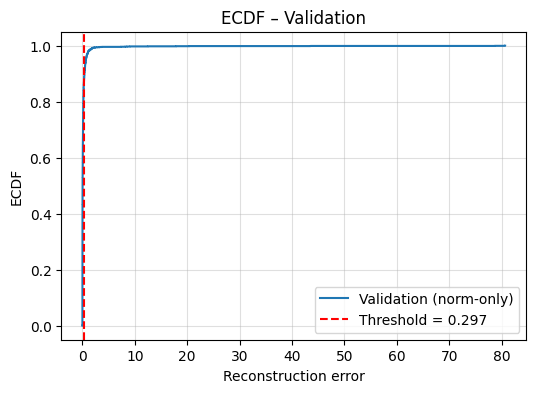

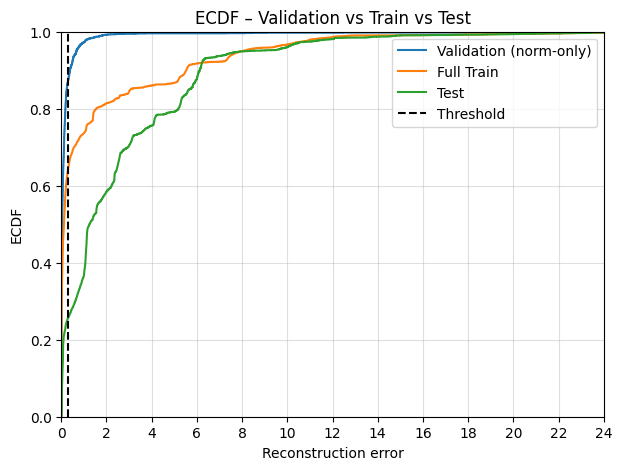

In [84]:
# -----------------------------------------------------------------
# THRESHOLD from validation normals  +  ECDF plot
# -----------------------------------------------------------------

threshold = 0.297364
print(f"Chosen threshold = {threshold:.6f}  (med + 8·MAD)")

# Plot ECDF for validation normals and mark threshold
sorted_val = np.sort(val_err)
ecdf_val   = np.arange(1,len(sorted_val)+1)/len(sorted_val)
plt.figure(figsize=(6,4))
plt.step(sorted_val, ecdf_val, where='post', label='Validation (norm‑only)')
plt.axvline(threshold, color='red', ls='--', label=f'Threshold = {threshold:.3f}')
plt.xlabel('Reconstruction error'); plt.ylabel('ECDF'); plt.title('ECDF – Validation')
plt.legend(); plt.grid(alpha=.4); plt.show()

# -----------------------------------------------------------------
#  ECDF curves for 3 datasets
# -----------------------------------------------------------------
# Helper to compute errors for an arbitrary NumPy matrix
def compute_errs(mat):
    loader = DataLoader(TensorDataset(torch.from_numpy(mat)), batch_size=BATCH_SIZE, shuffle=False)
    errs=[]
    with torch.no_grad():
        for (xb,) in loader:
            xb=xb.to(DEVICE); errs.append(per_sample_error(xb, model(xb)).cpu().numpy())
    return np.concatenate(errs)

X_full_train = df_train_preprocessed[feature_cols].values.astype(np.float32)
X_full_test  = df_test_preprocessed [feature_cols].values.astype(np.float32)

errs_train   = compute_errs(X_full_train)
errs_test    = compute_errs(X_full_test)

# Build ECDF curves
plt.figure(figsize=(7,5))
plt.xlim(0, 10); plt.ylim(0, 1)
plt.xticks(np.arange(0, 25, 2))
for data, label in [(val_err,'Validation (norm‑only)'),(errs_train,'Full Train'),(errs_test,'Test')]:
    s=np.sort(data); ecdf=np.arange(1,len(s)+1)/len(s)
    plt.step(s, ecdf, where='post', label=label)
plt.axvline(threshold, color='black', ls='--', label='Threshold')
plt.xlabel('Reconstruction error'); plt.ylabel('ECDF');
plt.title('ECDF – Validation vs Train vs Test'); plt.legend(); plt.grid(alpha=.4)
plt.show()

In [85]:
# Detailed analysis of reconstruction errors
def analyze_reconstruction_errors(val_err, train_err, test_err, threshold):
    """
    Provide detailed statistical analysis of reconstruction errors.
    """
    datasets = {
        'Validation (Normal only)': val_err,
        'Full Training': train_err,
        'Test': test_err
    }

    print("=== RECONSTRUCTION ERROR ANALYSIS ===\n")

    for name, errors in datasets.items():
        print(f"{name}:")
        print(f"  Count: {len(errors)}")
        print(f"  Mean:  {np.mean(errors):.6f}")
        print(f"  Std:   {np.std(errors):.6f}")
        print(f"  Min:   {np.min(errors):.6f}")
        print(f"  Max:   {np.max(errors):.6f}")
        print(f"  Q1:    {np.percentile(errors, 25):.6f}")
        print(f"  Median:{np.median(errors):.6f}")
        print(f"  Q3:    {np.percentile(errors, 75):.6f}")
        print(f"  P95:   {np.percentile(errors, 95):.6f}")
        print(f"  P99:   {np.percentile(errors, 99):.6f}")

        # Anomaly detection performance
        anomalies = np.sum(errors > threshold)
        anomaly_rate = anomalies / len(errors) * 100
        print(f"  Anomalies detected: {anomalies} ({anomaly_rate:.2f}%)")
        print()

    # Explain why errors increase from validation to train to test
    print("=== WHY ERRORS INCREASE ===")
    print("1. Validation → Full Training:")
    print("   - Full training contains anomalies that the model hasn't seen")
    print("   - Model was trained only on normal data, so anomalies have higher reconstruction error")
    print()
    print("2. Full Training → Test:")
    print("   - Test set may have different data distribution (domain shift)")
    print("   - Test anomalies might be more diverse or severe")
    print("   - Natural dataset drift over time")

# Usage
analyze_reconstruction_errors(val_err, errs_train, errs_test, threshold)

=== RECONSTRUCTION ERROR ANALYSIS ===

Validation (Normal only):
  Count: 2420
  Mean:  0.259332
  Std:   2.559873
  Min:   0.001548
  Max:   80.686432
  Q1:    0.008291
  Median:0.037221
  Q3:    0.147470
  P95:   0.669967
  P99:   1.787807
  Anomalies detected: 308 (12.73%)

Full Training:
  Count: 16917
  Mean:  1.598417
  Std:   6.282112
  Min:   0.001548
  Max:   531.365234
  Q1:    0.012567
  Median:0.117194
  Q3:    1.105650
  P95:   8.019653
  P99:   12.838804
  Anomalies detected: 6057 (35.80%)

Test:
  Count: 5771
  Mean:  2.815003
  Std:   14.241220
  Min:   0.003473
  Max:   1037.783203
  Q1:    0.261968
  Median:1.243440
  Q3:    3.788203
  P95:   8.305552
  P99:   14.806379
  Anomalies detected: 4293 (74.39%)

=== WHY ERRORS INCREASE ===
1. Validation → Full Training:
   - Full training contains anomalies that the model hasn't seen
   - Model was trained only on normal data, so anomalies have higher reconstruction error

2. Full Training → Test:
   - Test set may have dif

## AE - OC-SVM

emb_train_norm: (12102, 8), emb_train_all: (16917, 8)
emb_val:       (1884, 8),       emb_test:       (5771, 8)
Best OC-SVM → ν=0.01, γ=scale, F1(val)=0.475

=== OC-SVM on AE bottleneck – Train (all) ===
              precision    recall  f1-score   support

           0     0.7930    0.9898    0.8806     12102
           1     0.9321    0.3508    0.5097      4815

    accuracy                         0.8079     16917
   macro avg     0.8626    0.6703    0.6952     16917
weighted avg     0.8326    0.8079    0.7750     16917



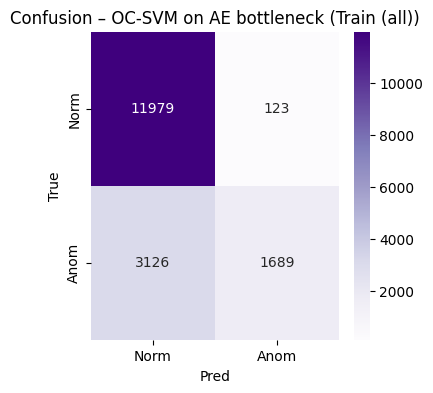


=== OC-SVM on AE bottleneck – Validation ===
              precision    recall  f1-score   support

           0     0.7845    0.9874    0.8743      1346
           1     0.9105    0.3216    0.4753       538

    accuracy                         0.7972      1884
   macro avg     0.8475    0.6545    0.6748      1884
weighted avg     0.8205    0.7972    0.7604      1884



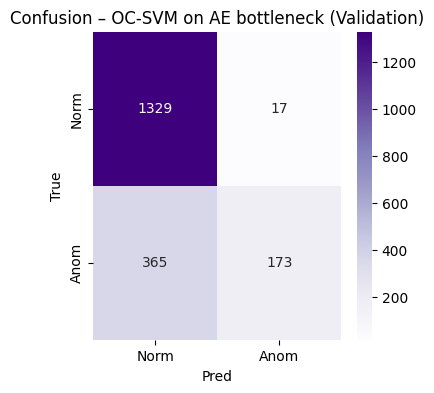


=== OC-SVM on AE bottleneck – Test ===
              precision    recall  f1-score   support

           0     0.4271    0.7751    0.5508      2152
           1     0.7406    0.3819    0.5039      3619

    accuracy                         0.5285      5771
   macro avg     0.5839    0.5785    0.5273      5771
weighted avg     0.6237    0.5285    0.5214      5771



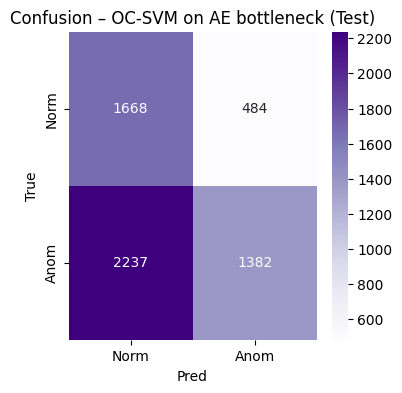

In [86]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Helper to extract AE bottleneck embeddings
def get_embeddings(X_np: np.ndarray, model, device, batch_size: int = 64) -> np.ndarray:
    loader = DataLoader(TensorDataset(torch.from_numpy(X_np)),
                        batch_size=batch_size, shuffle=False)
    embs = []
    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            z  = model.encode(xb)
            embs.append(z.cpu().numpy())
    return np.vstack(embs)

# — prepare raw feature matrices
X_train_norm_np = df_train_preprocessed.loc[
    df_train_preprocessed.binary_label == 0, feature_cols
].values.astype(np.float32)
X_train_all_np  = df_train_preprocessed[feature_cols].values.astype(np.float32)
X_val_np        = df_val_preprocessed[feature_cols].values.astype(np.float32)
X_test_np       = df_test_preprocessed[feature_cols].values.astype(np.float32)

y_train_all = df_train_preprocessed.binary_label.values  # 0/1 over all train
y_val       = df_val_preprocessed.binary_label.values
y_test      = df_test_preprocessed.binary_label.values

# — extract embeddings
emb_train_norm = get_embeddings(X_train_norm_np, model, DEVICE)
emb_train_all  = get_embeddings(X_train_all_np,  model, DEVICE)
emb_val        = get_embeddings(X_val_np,        model, DEVICE)
emb_test       = get_embeddings(X_test_np,       model, DEVICE)

print(f"emb_train_norm: {emb_train_norm.shape}, emb_train_all: {emb_train_all.shape}")
print(f"emb_val:       {emb_val.shape},       emb_test:       {emb_test.shape}")

#  – scale embeddings
scaler = StandardScaler().fit(emb_train_norm)
emb_train_norm_sc = scaler.transform(emb_train_norm)
emb_train_all_sc  = scaler.transform(emb_train_all)
emb_val_sc        = scaler.transform(emb_val)
emb_test_sc       = scaler.transform(emb_test)

#  – OC-SVM grid-search on normal‐only embeddings
nu_grid    = [0.0005, 0.001, 0.002, 0.005, 0.01]
gamma_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, "scale"]

best_svm_ae, best_nu_ae, best_gamma_ae, best_f1_ae = None, None, None, -np.inf

for nu in nu_grid:
    for g in gamma_grid:
        svm = OneClassSVM(kernel="rbf", nu=nu, gamma=g).fit(emb_train_norm_sc)

        y_val_pred = (svm.predict(emb_val_sc) == -1).astype(int)
        f1 = f1_score(y_val, y_val_pred)
        if f1 > best_f1_ae:
            best_f1_ae, best_svm_ae = f1, svm
            best_nu_ae, best_gamma_ae = nu, g

print(f"Best OC-SVM → \u03bd={best_nu_ae}, \u03b3={best_gamma_ae}, F1(val)={best_f1_ae:.3f}")

# – Evaluation on full train / validation / test
def eval_and_plot(name, y_true, emb_sc):
    y_pred = (best_svm_ae.predict(emb_sc) == -1).astype(int)
    print(f"\n=== OC-SVM on AE bottleneck – {name} ===")
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=["Norm","Anom"], yticklabels=["Norm","Anom"])
    plt.title(f"Confusion – OC-SVM on AE bottleneck ({name})")
    plt.xlabel("Pred"); plt.ylabel("True")
    plt.show()

eval_and_plot("Train (all)",      y_train_all, emb_train_all_sc)
eval_and_plot("Validation",       y_val,         emb_val_sc)
eval_and_plot("Test",             y_test,        emb_test_sc)

=== ADDITIONAL ANALYSIS ===

1. DIMENSIONALITY ANALYSIS
   Original features: 53
   AE bottleneck: 8
   Compression ratio: 0.151

2. EMBEDDING DISTRIBUTION ANALYSIS
   Normal samples in test: 2152
   Anomaly samples in test: 3619

3. DECISION BOUNDARY ANALYSIS
   Train normal scores: mean=0.6416, std=0.5229
   Test normal scores:  mean=-0.0028, std=0.8800
   Test anomaly scores: mean=0.1725, std=0.4613

4. 2D VISUALIZATION


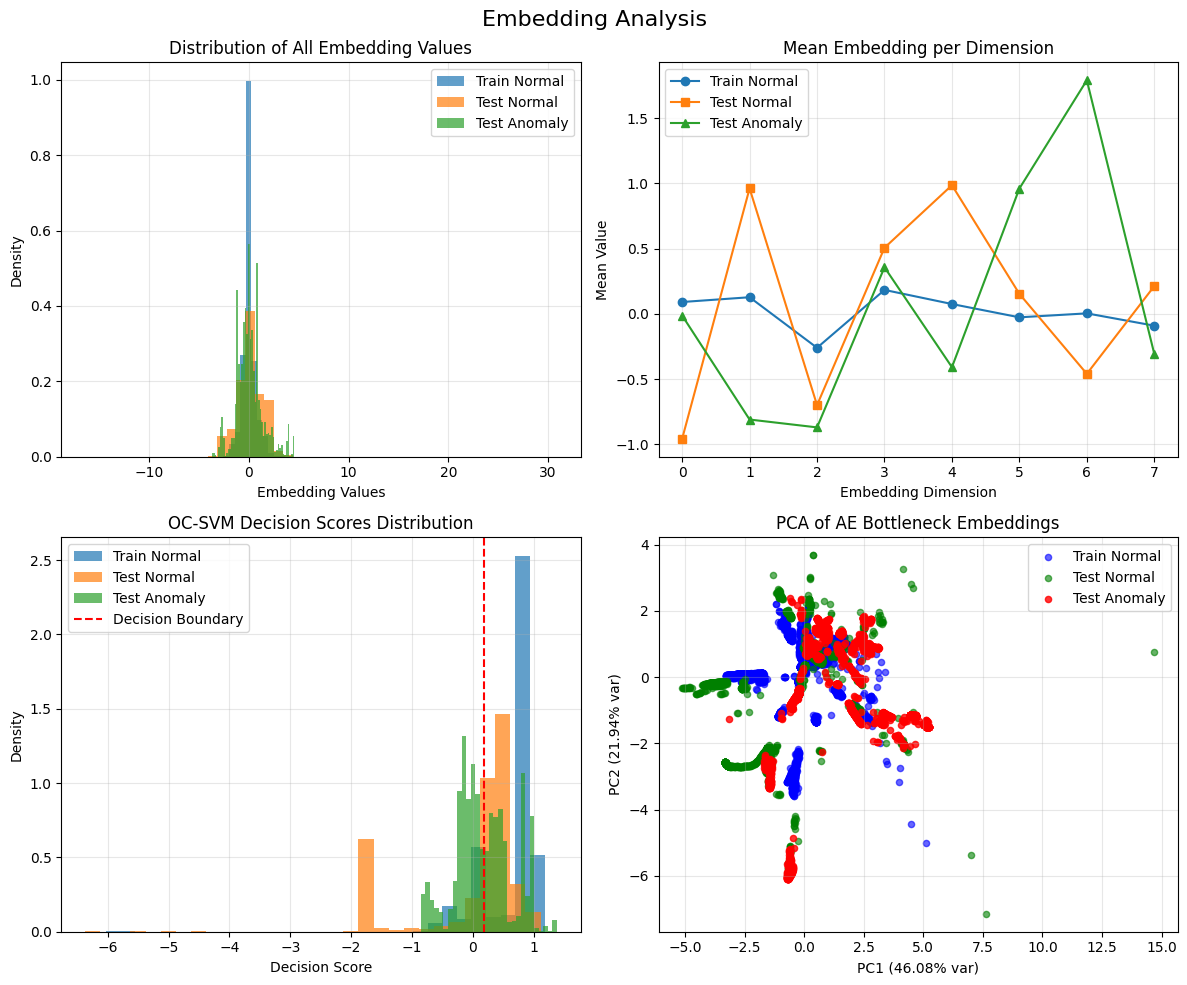

   PCA explained variance: 46.08% + 21.94% = 68.02%

5. EMBEDDING ANALYSIS
   Embedding variance per dimension:
     Dim 0: 0.3176
     Dim 1: 0.4926
     Dim 2: 0.3367
     Dim 3: 0.4287
     Dim 4: 0.2482
     Dim 5: 0.3222
     Dim 6: 0.4565
     Dim 7: 0.4478
   Most variable dimensions: [1 6 7] (higher variance often means more information)


In [87]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns

def additional_analysis(emb_train_norm, emb_test, y_test_bin, best_svm):
    """
    Additional analysis to understand the AE bottleneck approach
    """
    print("=== ADDITIONAL ANALYSIS ===\n")

    #  Dimensionality Analysis
    print("1. DIMENSIONALITY ANALYSIS")
    print(f"   Original features: {X_train_normal_only.shape[1]}")
    print(f"   AE bottleneck: {emb_train_norm.shape[1]}")
    print(f"   Compression ratio: {emb_train_norm.shape[1]/X_train_normal_only.shape[1]:.3f}")

    #  Distribution Analysis of Embeddings
    print(f"\n2. EMBEDDING DISTRIBUTION ANALYSIS")

    # Split test embeddings by true labels
    emb_test_normal = emb_test[y_test_bin == 0]
    emb_test_anomaly = emb_test[y_test_bin == 1]

    print(f"   Normal samples in test: {len(emb_test_normal)}")
    print(f"   Anomaly samples in test: {len(emb_test_anomaly)}")

    # Statistics per dimension
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Embedding Analysis', fontsize=16)

    #  Distribution of embedding values
    ax1 = axes[0, 0]
    ax1.hist(emb_train_norm.flatten(), bins=50, alpha=0.7, label='Train Normal', density=True)
    ax1.hist(emb_test_normal.flatten(), bins=50, alpha=0.7, label='Test Normal', density=True)
    ax1.hist(emb_test_anomaly.flatten(), bins=50, alpha=0.7, label='Test Anomaly', density=True)
    ax1.set_xlabel('Embedding Values')
    ax1.set_ylabel('Density')
    ax1.set_title('Distribution of All Embedding Values')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    #  Mean embedding per dimension
    ax2 = axes[0, 1]
    dims = range(emb_train_norm.shape[1])
    ax2.plot(dims, np.mean(emb_train_norm, axis=0), 'o-', label='Train Normal')
    ax2.plot(dims, np.mean(emb_test_normal, axis=0), 's-', label='Test Normal')
    ax2.plot(dims, np.mean(emb_test_anomaly, axis=0), '^-', label='Test Anomaly')
    ax2.set_xlabel('Embedding Dimension')
    ax2.set_ylabel('Mean Value')
    ax2.set_title('Mean Embedding per Dimension')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    #  Decision Boundary Analysis
    print(f"\n3. DECISION BOUNDARY ANALYSIS")

    # Get decision scores
    train_scores = best_svm.decision_function(emb_train_norm)
    test_scores = best_svm.decision_function(emb_test)
    test_scores_normal = test_scores[y_test_bin == 0]
    test_scores_anomaly = test_scores[y_test_bin == 1]

    print(f"   Train normal scores: mean={np.mean(train_scores):.4f}, std={np.std(train_scores):.4f}")
    print(f"   Test normal scores:  mean={np.mean(test_scores_normal):.4f}, std={np.std(test_scores_normal):.4f}")
    print(f"   Test anomaly scores: mean={np.mean(test_scores_anomaly):.4f}, std={np.std(test_scores_anomaly):.4f}")

    #  Decision scores distribution
    ax3 = axes[1, 0]
    ax3.hist(train_scores, bins=30, alpha=0.7, label='Train Normal', density=True)
    ax3.hist(test_scores_normal, bins=30, alpha=0.7, label='Test Normal', density=True)
    ax3.hist(test_scores_anomaly, bins=30, alpha=0.7, label='Test Anomaly', density=True)
    ax3.axvline(0.188868, color='red', linestyle='--', label='Decision Boundary')
    ax3.set_xlabel('Decision Score')
    ax3.set_ylabel('Density')
    ax3.set_title('OC-SVM Decision Scores Distribution')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    #  2D Visualization (PCA)
    print(f"\n4. 2D VISUALIZATION")

    # Apply PCA to embeddings for visualization
    pca = PCA(n_components=2, random_state=42)

    # Fit on training normals and transform all
    emb_all = np.vstack([emb_train_norm, emb_test])
    labels_all = np.concatenate([np.zeros(len(emb_train_norm)), y_test_bin])

    emb_2d = pca.fit_transform(emb_all)

    ax4 = axes[1, 1]

    # Plot points
    train_idx = len(emb_train_norm)
    ax4.scatter(emb_2d[:train_idx, 0], emb_2d[:train_idx, 1],
               c='blue', alpha=0.6, s=20, label='Train Normal')
    ax4.scatter(emb_2d[train_idx:][y_test_bin == 0, 0], emb_2d[train_idx:][y_test_bin == 0, 1],
               c='green', alpha=0.6, s=20, label='Test Normal')
    ax4.scatter(emb_2d[train_idx:][y_test_bin == 1, 0], emb_2d[train_idx:][y_test_bin == 1, 1],
               c='red', alpha=0.8, s=20, label='Test Anomaly')

    ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
    ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
    ax4.set_title('PCA of AE Bottleneck Embeddings')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"   PCA explained variance: {pca.explained_variance_ratio_[0]:.2%} + {pca.explained_variance_ratio_[1]:.2%} = {pca.explained_variance_ratio_[:2].sum():.2%}")

    #  Feature importance analysis (if possible)
    print(f"\n5. EMBEDDING ANALYSIS")

    # Variance per dimension
    var_per_dim = np.var(emb_train_norm, axis=0)
    print(f"   Embedding variance per dimension:")
    for i, var in enumerate(var_per_dim):
        print(f"     Dim {i}: {var:.4f}")

    # Most informative dimensions
    top_dims = np.argsort(var_per_dim)[::-1][:3]
    print(f"   Most variable dimensions: {top_dims} (higher variance often means more information)")

    return {
        'pca_variance': pca.explained_variance_ratio_,
        'decision_scores': {
            'train_normal': train_scores,
            'test_normal': test_scores_normal,
            'test_anomaly': test_scores_anomaly
        },
        'embedding_variance': var_per_dim
    }

# Execute additional analysis
additional_results = additional_analysis(
    emb_train_norm,
    emb_test_sc,
    y_test,
    best_svm_ae
)


## PCA and OC-SVM

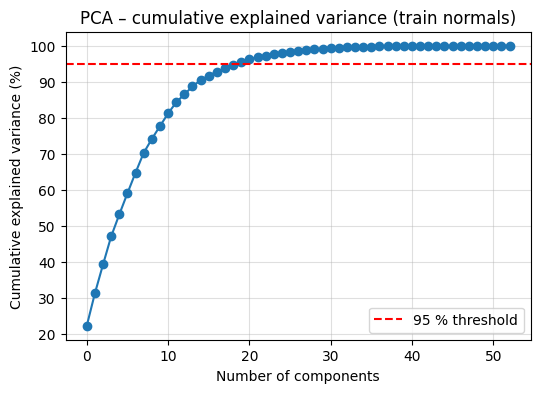

Chosen PCA components (elbow)  k = 20  → cum_var = 95.47%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


OC-SVM (PCA) scelto   ν=0.01   γ=0.1   |  F1(val)=0.858

=== OC-SVM on PCA components – Test set ===
              precision    recall  f1-score   support

           0     0.7147    0.7370    0.7257      2152
           1     0.8407    0.8251    0.8328      3619

    accuracy                         0.7922      5771
   macro avg     0.7777    0.7810    0.7792      5771
weighted avg     0.7937    0.7922    0.7929      5771



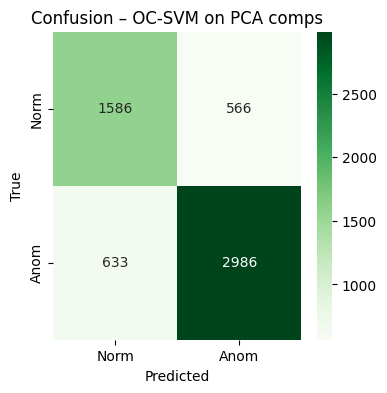

In [88]:
# ================================================================
#  PCA → OC-SVM pipeline (normal-only train)
# ------------------------------------------------

from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix

# ----------   FIT PCA on normal-only train ----------


pca_full = PCA().fit(X_train_normal_only)
           # full spectrum
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100   # %

# plot cumulative explained variance
plt.figure(figsize=(6,4))
plt.plot(cum_var, marker="o")
plt.axhline(95, ls="--", c="red", label="95 % threshold")
plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance (%)")
plt.title("PCA – cumulative explained variance (train normals)")
plt.grid(alpha=.4); plt.legend(); plt.show()

# ----------  elbow / k selection ----------
# heuristic: first k with cum_var ≥ 95 %  AND marginal gain < 1 %
marginal = np.diff(np.insert(cum_var, 0, 0))
k = next(i+1 for i,(cv,dv) in enumerate(zip(cum_var, marginal))
         if cv >= 95 and dv < 1)

print(f"Chosen PCA components (elbow)  k = {k}  → cum_var = {cum_var[k-1]:.2f}%")

pca   = PCA(n_components=k, random_state=42).fit(X_train_normal_only)
X_trk = pca.transform(X_train_normal_only)                 # (N_train_norm, k)

sc_pca = StandardScaler().fit(X_trk)
X_train_pca = sc_pca.transform(X_trk)


X_ts_k      = pca.transform(X_test)
X_test_pca  = sc_pca.transform(X_ts_k)


# ----------   OC-SVM on PCA-features ----------
# -------------------------------------------------------------
#   Prepara validation set (normali + anomalie)
# -------------------------------------------------------------
X_val_np   = df_val_preprocessed[feature_cols].values.astype(np.float32)
y_val_bin  = df_val_preprocessed["binary_label"].values            # 0 = norm, 1 = anom

# stesso identico pre-processing di train
X_val_pca  = sc_pca.transform(pca.transform(X_val_np))

# -------------------------------------------------------------
#   Grid-search driver by F1(val)
# -------------------------------------------------------------
from sklearn.metrics import f1_score

nu_grid    = [0.0005, 0.001, 0.002, 0.005, 0.01]
gamma_grid = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, "scale"]

best_svm, best_cfg, best_f1 = None, None, -1

for nu in nu_grid:
    for g in gamma_grid:
        svm = OneClassSVM(kernel="rbf", nu=nu, gamma=g).fit(X_train_pca)


        y_val_pred = (svm.predict(X_val_pca) == -1).astype(int)
        f1 = f1_score(y_val_bin, y_val_pred, pos_label=1)

        if f1 > best_f1:
            best_f1, best_svm, best_cfg = f1, svm, (nu, g)

print(f"OC-SVM (PCA) scelto   ν={best_cfg[0]}   γ={best_cfg[1]}   |  F1(val)={best_f1:.3f}")


# ----------   TEST evaluation ----------
y_pred_pca = (best_svm.predict(X_test_pca) == -1).astype(int)

print("\n=== OC-SVM on PCA components – Test set ===")
print(classification_report(y_test, y_pred_pca, digits=4))

cm_pca = confusion_matrix(y_test, y_pred_pca)
plt.figure(figsize=(4,4))
sns.heatmap(cm_pca, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Norm","Anom"], yticklabels=["Norm","Anom"])
plt.title("Confusion – OC-SVM on PCA comps")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()
